# POC SDD-LCA 2026

Ce notebook propose un **deroule de presentation scientifique**, mais lisible pour un public operationnel.

Objectif : montrer que le `State-Dependent Dynamic LCA (SDD)` n'est pas seulement une LCA plus detaillee, mais une methode qui :
- capte des impacts rates par la `LCA classique` et par la `time-dependent DLCA` ;
- explique **pourquoi** ces impacts apparaissent ;
- change la lecture des politiques operationnelles et des arbitrages.

Le fil narratif retenu est :
1. La `LCA classique` agrege les flux et sous-estime l'impact du cas etudie.
2. La `time-dependent DLCA` reintroduit correctement la sequence temporelle des flux et des facteurs, et s'ecarte deja du resultat classique.
3. Le `SDD` ajoute la dependance a l'etat operationnel endogene et revele un sur-impact supplementaire important.
4. Cette difference compte pour interpreter le systeme et comparer des politiques de pilotage.

Les annexes en fin de notebook completent la lecture pour un public plus technique.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'outputs_sddlca_poc').exists():
    NOTEBOOK_DIR = Path('/workspaces/lca-simu/POC2026')

CSV_DIR = NOTEBOOK_DIR / 'outputs_sddlca_poc' / 'csv'
IMG_DIR = NOTEBOOK_DIR / 'outputs_sddlca_poc' / 'images'

comparison = pd.read_csv(CSV_DIR / 'poc_lca_method_comparison.csv')
key_metrics = pd.read_csv(CSV_DIR / 'poc_key_metrics.csv')
decision_summary = pd.read_csv(CSV_DIR / 'poc_policy_decision_summary.csv')
breakdown = pd.read_csv(CSV_DIR / 'poc_lca_breakdown.csv')

def show_image(filename: str, width: int = 1000):
    return Image(filename=str(IMG_DIR / filename), width=width)

display(Markdown('## Donnees chargees'))
display(comparison.round(2))


## Donnees chargees

,method,total_kgCO2e,delta_vs_classical,delta_vs_classical_pct
0,Classical LCA,19673.48,0.00,0.00
1,Time-Dependent DLCA,19457.82,-215.66,-1.10
2,State-Dependent Dynamic LCA,23169.80,3496.33,17.77


## Selection resserree des graphes a conserver

Pour une presentation courte, je conserverais prioritairement :

1. `poc_weekly_impact_comparison.png`
   pour montrer que l'ecart apparait dans le temps.
2. `poc_sdd_gap_drivers.png`
   pour montrer d'ou vient l'ecart du SDD.
3. `poc_state_space_method_comparison.png`
   pour montrer ce que voit chaque methode.
4. `poc_policy_method_gap.png`
   pour montrer que l'ecart reste present quand on compare des politiques.
5. `poc_policy_decision_frontier.png`
   pour montrer l'apport du SDD a la decision.

Les annexes utiles sont ensuite :
- `poc_policy_causal_attribution.png`
- `poc_sensitivity_volume_intensity.png`
- `poc_source_traceability.png`
- `poc_state_space_projection.png`


## Vocabulaire minimal du POC

Pour eviter les ambiguities pendant la presentation, voici le vocabulaire a utiliser de facon stable :

- `Production utile` : nombre de produits finis fabriques sans rebut pendant la semaine. C'est un **flux**.
- `Expeditions client` : nombre de produits finis effectivement envoyes au client pendant la semaine. C'est un **flux aval**.
- `Stock MP` : stock de matieres premieres disponible pour produire.
- `Stock PF` : stock de produits finis deja fabriques mais pas encore expedies.
- `Stock total` : `stock MP + stock PF`. C'est une vue agregee, utile pour la `LCA classique` et pour la `time-dependent DLCA`.
- `Matieres en transit` : matieres deja commandees mais pas encore recues. Ce n'est **pas** une expedition client.
- `Backlog` : demande non servie, reportee a la periode suivante.
- `Backup` : fournisseur ou source de secours, plus carbones dans ce POC.
- `Scrap` : matiere et energie consommees pour produire des unites qui ne seront finalement pas livrees.

Point important :
- la `LCA classique` voit surtout des agregats ;
- la `time-dependent DLCA` voit des evolutions temporelles ;
- le `SDD` voit les evolutions temporelles **et** les etats operationnels qui expliquent ces evolutions.


## 0. Mise en contexte operationnelle

Avant d'entrer dans la comparaison des methodes, il est utile de fixer **le systeme physique** et **la chronologie des evenements**.

Pourquoi cette introduction est utile :
- elle ancre les graphes carbone dans une supply chain concrete ;
- elle permet de visualiser les moments ou le systeme change de regime ;
- elle rend plus intuitive la lecture du `SDD`, qui depend justement de ces changements d'etat.

Comment lire cette introduction :
- le schema de supply chain rappelle la structure du POC : fournisseurs, usine, entrepot, client ;
- la chronologie montre les evenements operationnels significatifs : reception du `backup`, usage du `backup`, passage en `aerien`, apparition de `scrap`.

Question importante :
- **Pourquoi commencer par cela ?**
  Parce que la these du POC est que les impacts carbone emergent de la dynamique operationnelle. Il faut donc d'abord voir le systeme et ses evenements avant d'interpreter les resultats LCA.


## 0 bis. Contexte scientifique et etat de l'art

Avant d'interpreter le POC, il faut situer clairement la contribution par rapport a la litterature recente sur la `Dynamic LCA` et sur la dynamique des supply chains.

### 1. LCA classique

Dans sa forme standard, l'ACV classique calcule un impact a partir de flux inventaires agreges et de facteurs de caracterisation :

`I_k = somme_i q_i * CF_(i,k)`

Cette formulation est tres utile pour comparer des produits, des materiaux ou des procedes sur un horizon donne. En revanche, elle represente souvent les systemes operationnels a partir de volumes moyens, de transports moyens ou de mixes energetiques moyens. Elle suppose donc implicitement un comportement quasi stationnaire. Le texte de revue que tu as fourni rappelle bien que cette hypothese devient fragile des que le systeme evolue fortement dans le temps ou subit des perturbations.

### 2. Dynamic LCA / Time-Dependent DLCA

La litterature sur la `Dynamic LCA` introduit ensuite le temps dans l'inventaire, dans la caracterisation ou dans les scenarios de fond :

`I_k = somme_t somme_i q_i(t) * CF_(i,k)(t)`

Les references structurantes citees dans ta revue sont coherentes avec cet etat de l'art :
- `Levasseur et al. (2010)` pour la formulation fondatrice des impacts climatiques dynamiques ;
- `Beloin-Saint-Pierre et al. (2014, 2017)` pour l'implementation et la temporalisation des flux ;
- `Sohn et al. (2020)` pour la clarification des differents types de `Dynamic LCA` ;
- `Lueddeckens et al. (2020)` pour les questions de temporal boundary, de discounting et de sensibilite ;
- `Cornago et al. (2022)` pour la `dynamic life cycle inventory` et les perspectives Industry 4.0 ;
- `Pigné et al. (2020)`, `Pinsonnault (2013)` et `Pinsonnault et al. (2014)` pour la temporalisation de la base de fond ;
- `Cardellini & Mutel (2018)` pour les outils de calcul type `Temporalis`.

Dans cette famille d'approches, la dynamique vient typiquement :
- d'emissions distribuees dans le temps ;
- de facteurs de caracterisation dependants du temps ;
- de systemes de fond evolutifs, par exemple un mix electrique qui se decarbone ;
- de scenarios prospectifs technologiques ou energetiques.

Le point important, confirme par `Sohn et al. (2020)` et par la synthese bibliographique, est que cette temporalite reste tres souvent **exogene** au systeme operationnel. Les trajectoires sont prescrites par scenario, calendrier ou base de donnees, plutot que generees par les feedbacks internes du systeme etudie.

### 3. Modeles dynamiques de supply chain

En parallele, la litterature en `System Dynamics` et en `supply chain dynamics` montre que les systemes industriels sont gouvernes par :
- des stocks et flux ;
- des delais ;
- des boucles de retroaction ;
- des regles de decision ;
- des non-linearites ;
- des phenomenes comme le bullwhip, les oscillations ou la propagation de perturbations.

Dans cette litterature, le systeme est formalise comme un systeme dynamique du type :

`x_(t+1) = f(x_t, u_t, w_t)`

avec `x_t` l'etat du systeme, `u_t` les decisions et `w_t` les perturbations.

Ta revue cite a ce titre des points d'appui importants : `Yi et al. (2023)` sur l'integration `LCA + system dynamics`, `Shekhar et al. (2025)` sur dynamique, resilience et supply chains durables, `Harraki et al. (2024)` sur le couplage data-driven de decisions de sourcing bas carbone, ainsi que `Hülagü et al. (2025)` et `Reinert et al. (2020, 2022)` sur l'articulation avec optimisation et systemes energetiques.

### 4. Le vrai manque dans la litterature

Le point de jonction entre ces corpus reste encore peu travaille :
- la litterature ACV voit surtout le **temps** ;
- la litterature SD / supply chain voit surtout la **dynamique interne du systeme** ;
- peu de travaux analysent comment cette dynamique interne fait basculer le systeme entre plusieurs **regimes environnementaux**.

La revue confirme d'ailleurs trois limites recurrentes :
- fragmentation methodologique des approches `Dynamic LCA` ;
- temporalisation encore partielle des systemes de fond ;
- difficultes d'integration complete avec optimisation, system dynamics et outils digitaux.

Autrement dit, la question n'est plus seulement :
- *quand les emissions ont-elles lieu ?*

mais aussi :
- *dans quel etat operationnel le systeme etait-il quand elles ont eu lieu ?*
- *quels mecanismes ont provoque le passage d'un regime environnemental a un autre ?*

## 0 ter. Positionnement scientifique de la contribution

### 1. De la dependance temporelle a la dependance a l'etat

Le cadre propose ici peut etre formule comme une `State-Dependent Dynamic LCA`, c'est-a-dire une evaluation environnementale dans laquelle l'impact depend a la fois du temps et de l'etat operationnel du systeme :

`I_k(t) = g_k(x_t, q(t), CF(t))`

ou, de maniere plus explicite,

`I_k = somme_t somme_i q_i(t, x_t) * CF_(i,k)(t, x_t)`

Dans cette formulation :
- l'etat `x_t` influence les decisions et les flux ;
- les flux inventaires deviennent des sorties d'un systeme dynamique ;
- l'impact environnemental emerge du comportement du systeme, et non plus seulement d'un produit moyen ou d'un scenario temporel impose.

Cette lecture est compatible avec l'evolution de la litterature, mais elle va plus loin que la plupart des cadres classes comme `Dynamic LCA` dans `Sohn et al. (2020)` ou dans la revue bibliographique fournie.

### 2. Regimes environnementaux

La discussion scientifique la plus forte n'est pas seulement `state-dependent`, mais aussi **regime-based**.

L'idee est qu'une supply chain peut passer entre plusieurs regimes operationnels-environnementaux :
- **regime nominal** : fournisseur principal, transport standard, rendement stable ;
- **regime tendu** : backlog qui monte, stocks bas, charge elevee ;
- **regime de crise** : recours au `backup`, transport aerien, surcharge et rebut.

Chaque regime a une signature environnementale propre. Le vrai saut scientifique consiste alors a etudier non seulement les niveaux d'impact, mais aussi les **transitions de regime** qui font apparaitre des surcouts environnementaux non lineaires.

Cette idee est tres coherente avec les ouvertures de la revue sur la resilience, les non-linearites, la digitalisation et l'integration avec la dynamique industrielle, mais elle n'apparait pas encore comme un cadre stabilise de la litterature. C'est la que la contribution peut devenir originale.

### 3. Gap de recherche vise par le POC

Le `POC` ne pretend pas couvrir tout le champ de la `Dynamic LCA`, ni toute la richesse de la `System Dynamics`. En revanche, il vise un gap tres precis :

> montrer qu'une part importante des sur-impacts environnementaux peut etre expliquee par des transitions de regime generees endogenement par la dynamique d'une supply chain.

Cela permet de reformuler la contribution de maniere plus ambitieuse :
- niveau **methodologique** : `State-Dependent Dynamic LCA` ;
- niveau **scientifique** : analyse des **regimes environnementaux** et de leurs mecanismes de transition dans des supply chains dynamiques.

### 4. Pourquoi c'est utile pour l'operationnel

Cette lecture est plus convaincante pour un public operationnel qu'un simple indicateur CO2 moyen. Elle permet de repondre a des questions directement actionnables :
- quels etats du systeme provoquent les derives carbone ?
- quels seuils de backlog, de stock ou de charge ne doivent pas etre franchis ?
- quels buffers ou quelles politiques evitent les basculements vers des regimes tres carbonés ?

Autrement dit, l'interet du `SDD` n'est pas seulement d'etre plus detaille. Il est de relier les impacts environnementaux a des **mecanismes de pilotage**, donc a des leviers de decision.

### 5. Ce que le POC demontre vraiment

Le POC Python qui suit ne constitue pas une preuve generale. Il sert a illustrer, sur un cas simple mais interpretable, trois niveaux de representation :
- `LCA classique` : vision agregee et stationnaire ;
- `Time-Dependent DLCA` : vision temporelle ;
- `SDD` : vision temporelle enrichie par l'etat et les transitions de regime.

Le bon niveau d'interpretation est donc :
- un **proof-of-concept methodologique** ;
- un **demonstrateur de regimes environnementaux** dans une supply chain dynamique ;
- une base credible pour structurer ensuite un vrai article scientifique.

### 6. Point de prudence scientifique

La revue bibliographique que tu as fournie est tres utile pour cartographier le champ, mais elle reste une **synthese secondaire**. Pour un article, il faudra donc s'appuyer directement sur quelques references pivots du corpus primaire plutot que sur la revue seule, en particulier `Levasseur et al. (2010)`, `Beloin-Saint-Pierre et al. (2014, 2017)`, `Sohn et al. (2020)`, `Lueddeckens et al. (2020)`, `Pigné et al. (2020)`, `Cornago et al. (2022)`, `Yi et al. (2023)` et `Hülagü et al. (2025)`.


## 0 quater. Research gap, regimes environnementaux et angle d'article

Le document bibliographique ajoute une clarification importante : la plupart des approches `Dynamic LCA` decrites dans la litterature introduisent le **temps**, mais tres rarement la **dynamique endogene du systeme operationnel** qui genere les flux environnementaux.

### 1. Research gap

Le `research gap` peut etre formule proprement ainsi :

- l'`ACV classique` voit surtout des flux moyens ;
- la `Dynamic LCA` voit surtout des flux ou des facteurs qui changent dans le temps ;
- les modeles de supply chain dynamique voient des stocks, delais, feedbacks et transitions de comportement ;
- mais peu de travaux couplent ces deux dimensions pour montrer comment la dynamique interne du systeme fait basculer l'impact environnemental.

Autrement dit, le manque n'est pas seulement une question de resolution temporelle. C'est une question de **causalite systemique**.

La revue renforce ce point en identifiant comme gaps prioritaires :
- la temporalisation insuffisante des systemes de fond ;
- l'absence de cadres pleinement couples `LCA + optimization + supply chain dynamics` ;
- le manque de standardisation sur les horizons temporels, le discounting et le reporting ;
- les difficultes de passage vers des outils industrialisables et inter-operables.

### 2. Pourquoi la notion de regime est utile

La notion de `state-dependent` est correcte mathematiquement, mais la notion de **regime environnemental** est souvent plus forte scientifiquement et plus lisible pour un lecteur.

Un regime environnemental designe un mode de fonctionnement relativement coherent du systeme, associe a :
- une structure operationnelle ;
- des mecanismes dominants ;
- une intensite environnementale caracteristique.

Dans ce POC, on peut interpreter par exemple :
- un **regime nominal** : fournisseur principal, camion, intensite energetique nominale, peu ou pas de rebut ;
- un **regime tendu** : backlog qui apparait, stocks qui baissent, charge qui monte ;
- un **regime de crise** : `backup`, transport aerien, surcharge productive, rebut explicite.

Cette lecture est plus puissante qu'une simple comparaison de niveaux moyens, parce qu'elle permet de parler de **transitions de regime**, donc de seuils, de basculements et de non-linearites.

### 3. Formulation conceptuelle plus forte

Le cadre peut alors etre decompose en trois couches :

1. **Dynamique du systeme**

`x_(t+1) = f(x_t, u_t, w_t)`

2. **Identification du regime**

`r_t = Phi(x_t)`

avec `r_t` le regime courant (`nominal`, `tendu`, `crise`, `recuperation`, etc.).

3. **Impact environnemental conditionne par l'etat ou le regime**

`I_t = g(x_t, r_t, q_t, CF_t)`

Cette couche intermediaire `regime` est utile scientifiquement parce qu'elle rend l'explication plus interpretable : on ne dit plus seulement que l'impact depend de l'etat, on dit qu'il existe des **modes environnementaux distincts** du systeme.

### 4. Ce que cela permet de demontrer

Avec cet angle, un article ne viserait pas seulement a montrer que le `SDD` donne un chiffre plus eleve. Il pourrait viser a montrer :
- l'existence de regimes environnementaux distincts ;
- l'existence de transitions non lineaires entre ces regimes ;
- l'effet de la structure de la supply chain sur la frequence de ces regimes ;
- l'effet de buffers ou de politiques de resilience sur l'evitement des regimes fortement carbonés.

Cette perspective fait directement echo aux themes saillants de la revue : `system dynamics and resilience`, `integration with supply chain optimization`, `digitalization`, et `translation into industrial decision-making`.

### 5. Comment vendre la contribution

Il est utile de distinguer deux niveaux :

- **niveau methode** : `State-Dependent Dynamic LCA` ;
- **niveau contribution scientifique** : analyse des **transitions de regimes environnementaux** dans des supply chains dynamiques.

Cette seconde formulation est souvent plus forte vis-a-vis d'un jury, d'un reviewer ou d'un lecteur operationnel, parce qu'elle relie directement :
- la dynamique du systeme ;
- les mecanismes de degradation ;
- et les consequences environnementales.

### 6. Structure de papier cible

Une structure d'article naturelle devient alors :

1. **Research gap** : ce que la litterature ACV temporelle et la litterature supply chain dynamique ne couplent pas encore clairement.
2. **Methodology** : architecture du modele couple `system dynamics + environmental layer`, definitions de `x_t`, `q_i(t, x_t)` et eventuellement `r_t`.
3. **Proof-of-concept experiment** : le POC Python, avec comparaison `LCA classique` / `Time-Dependent DLCA` / `SDD`.
4. **Results and interpretation** : demonstration des sur-impacts, des mecanismes et des regimes.
5. **Implications** : pilotage, resilience, buffers, architecture de supply chain.

Dans cette perspective, le POC ne sert pas seulement a illustrer une nouvelle ACV. Il sert a montrer que les impacts environnementaux peuvent etre compris comme une **propriete emergente de la dynamique et des transitions de regime du systeme industriel**.


## 0 quinquies. References reperes pour un article

Pour transformer ce notebook en base de papier scientifique, voici les references les plus structurantes a mobiliser en priorite.

### 1. Fondations de la Dynamic LCA
- `Levasseur et al. (2010)` : formulation fondatrice de la `dynamic LCA` appliquee au changement climatique.
- `Beloin-Saint-Pierre et al. (2014)` : methode `ESPA` pour la differentiation temporelle des flux.
- `Beloin-Saint-Pierre et al. (2017)` : implementation operationnelle avec etude de cas.
- `Sohn et al. (2020)` : revue et clarification des differentes formes de `Dynamic LCA`.
- `Lueddeckens et al. (2020)` : revue systematique des questions temporelles en ACV.

### 2. Temporalisation des inventaires et des systemes de fond
- `Pinsonnault (2013)` et `Pinsonnault et al. (2014)` : pertinence de la temporalisation des bases de donnees de fond.
- `Pigné et al. (2020)` : outil pour operationaliser une `dynamic LCA` avec temporalisation complete de la base de fond.
- `Cardellini & Mutel (2018)` : logiciel `Temporalis`.
- `Cornago et al. (2022)` : revue systematique sur la `dynamic life cycle inventory` et les applications Industry 4.0.

### 3. Couplage avec system dynamics, optimisation et supply chains
- `Yi et al. (2023)` : revue systematique sur l'integration `LCA + system dynamics`.
- `Hülagü et al. (2025)` : integration de l'ACV dans l'optimisation de supply chain.
- `Reinert et al. (2020, 2022)` : couplage entre optimisation de systemes energetiques et ACV.
- `Harraki et al. (2024)` : decisions de sourcing bas carbone dans une supply chain dynamique.
- `Shekhar et al. (2025)` : dynamique, resilience et design de supply chains durables.

### 4. Digitalisation et implementation operationnelle
- `Madarkar et al. (2024)` : perspectives des digital twins pour la `dynamic LCA`.
- `Baylis-Green (2023)` : plateformes digitales pour `dynamic LCA` et `LCC`.
- `Rovelli et al. (2022)` : gestion modulaire des donnees ACV en contexte industriel.
- `Helo et al. (2024)` : gestion des donnees d'impact environnemental sur plateformes produits.

### 5. Message de positionnement bibliographique
Le bon usage de cette bibliographie dans un article serait de montrer que :
- la `Dynamic LCA` est deja bien etablie comme famille de methodes temporelles ;
- l'integration avec optimisation, digitalisation et system dynamics commence a emerger ;
- mais la lecture en **regimes environnementaux endogenes** reste encore peu formalisee comme telle.

C'est a cet endroit que le `SDD` et le POC peuvent prendre une vraie place scientifique.


### Structure de la supply chain

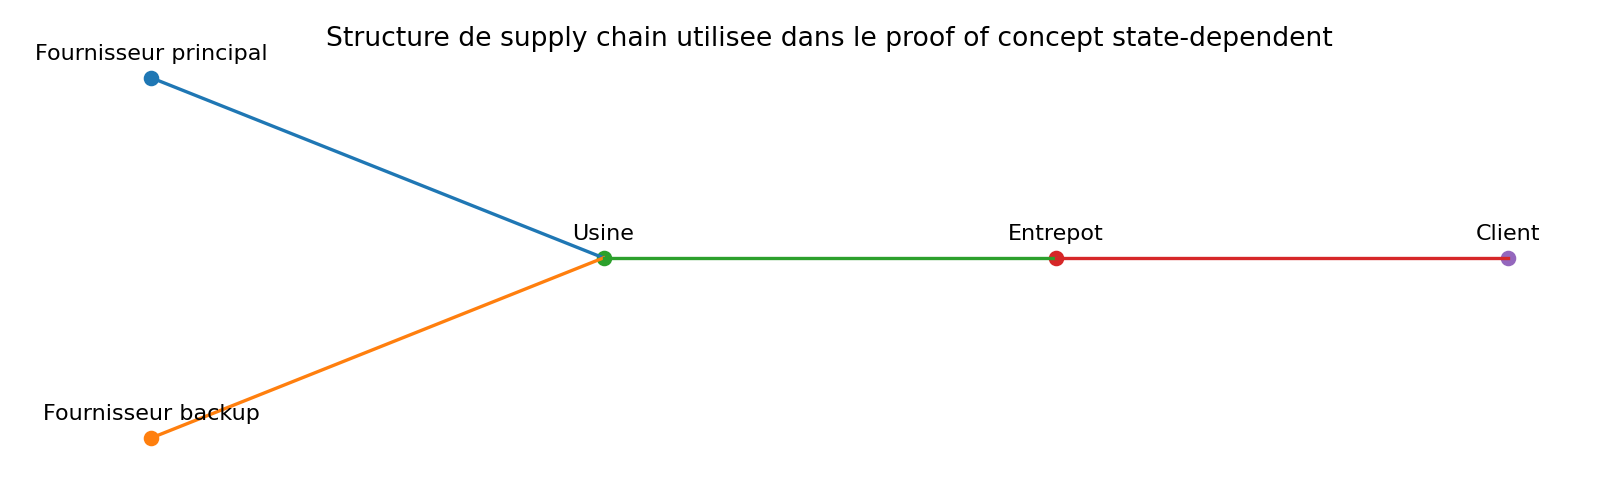

### Chronologie des evenements operationnels

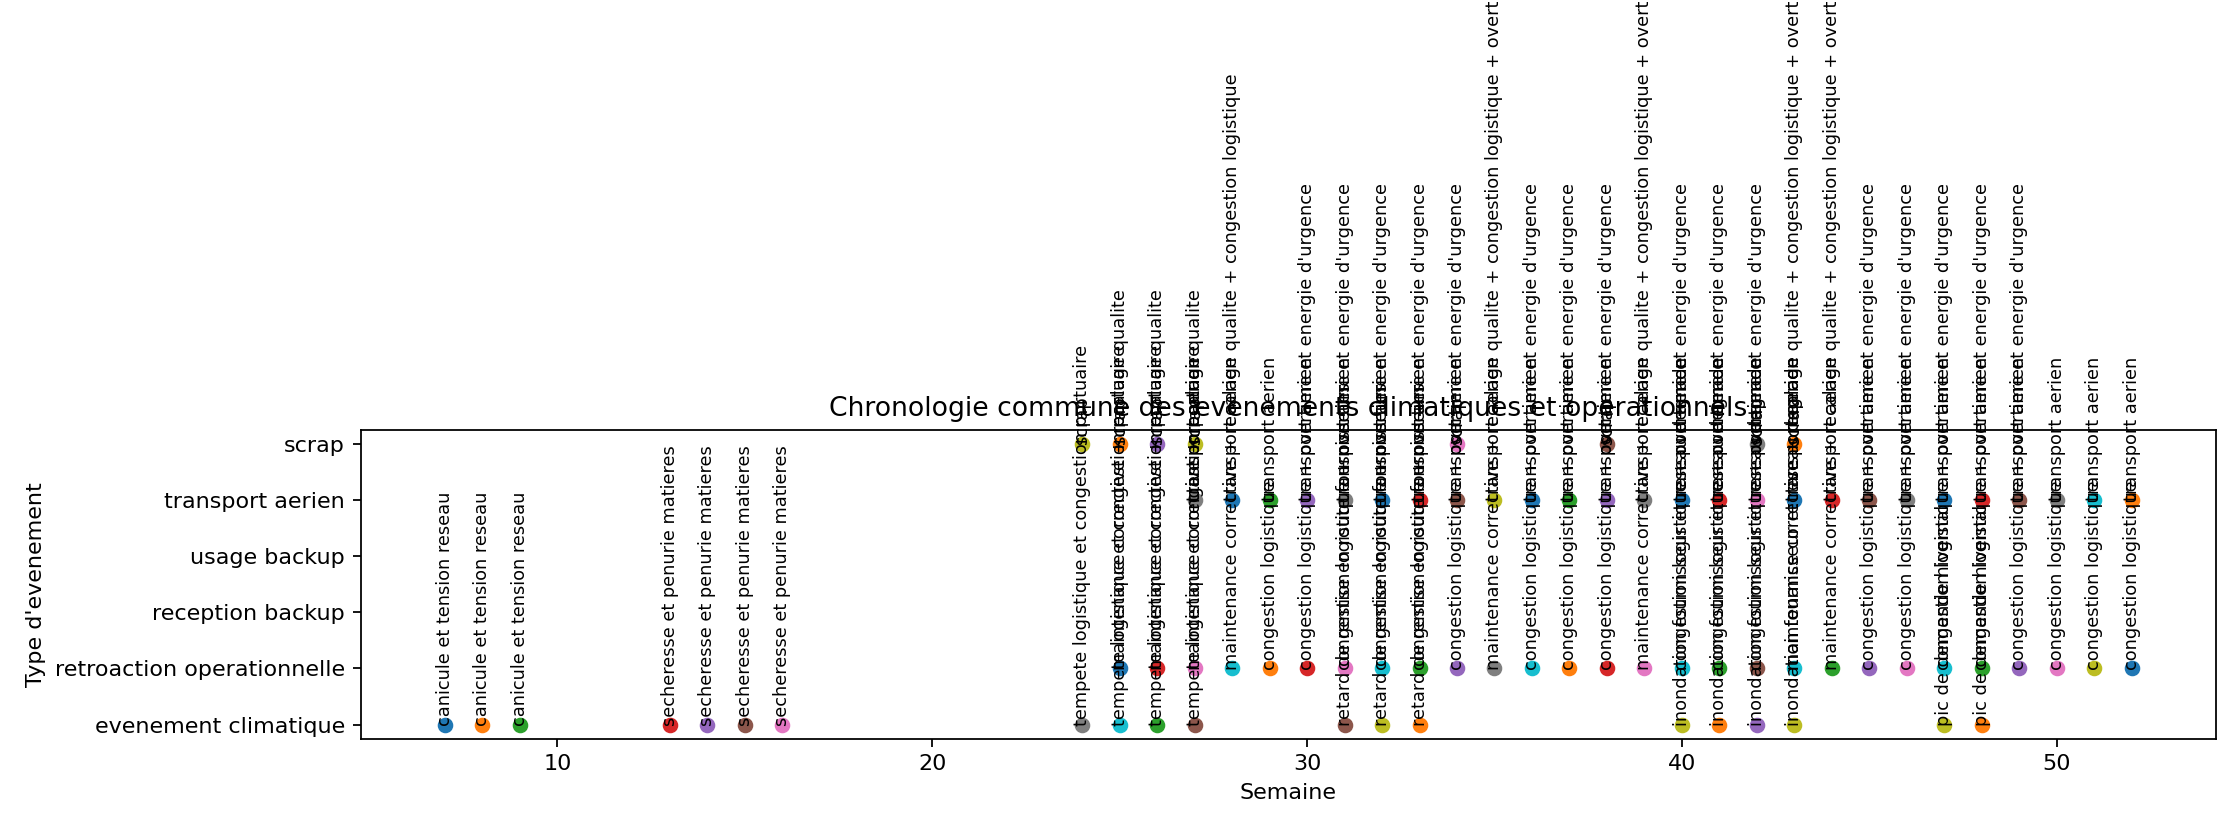

In [2]:
display(Markdown('### Structure de la supply chain'))
display(show_image('poc_supply_chain_schematic.png', width=850))
display(Markdown('### Chronologie des evenements operationnels'))
display(show_image('poc_event_timeline.png', width=900))


## 1. Resultat principal

Le premier message a faire passer est simple : sur ce POC, les trois methodes ne racontent deja plus la meme histoire sur une meme trajectoire annuelle. La `Time-Dependent DLCA` repond a la chronologie explicite des flux et des facteurs, tandis que le `SDD` revele en plus les sur-impacts lies aux basculements de regime operationnel.

Ce point doit toutefois etre formule proprement :
- les trois methodes sont appliquees a une **meme trajectoire operationnelle simulee** ;
- ce qui change d'une methode a l'autre, ce sont les **hypotheses environnementales** et le **niveau de dependance au temps ou a l'etat** ;
- la courbe hebdomadaire de `LCA classique` qui apparait dans certains graphes n'est pas une ACV classique "semaine par semaine" au sens strict, mais un **profil reconstruit** a partir d'hypotheses stationnaires afin de faciliter la comparaison visuelle.

C'est le bon point de depart pour toute la demonstration, car il montre a la fois :
- que la chronologie des flux compte deja ;
- que la dependance a l'etat ajoute encore une couche d'impact que la simple dynamique temporelle ne capte pas.


In [3]:
display(Markdown('### Chiffres cles'))
display(comparison.round(2))

display(Markdown('### Metriques operationnelles cles'))
display(key_metrics.head(10))

### Chiffres cles

,method,total_kgCO2e,delta_vs_classical,delta_vs_classical_pct
0,Classical LCA,19673.48,0.00,0.00
1,Time-Dependent DLCA,19457.82,-215.66,-1.10
2,State-Dependent Dynamic LCA,23169.80,3496.33,17.77


### Metriques operationnelles cles

,metric,value
0,Weeks with air outbound,26.00
1,Weeks with backup supplier activated,0.00
2,Weeks with backup material consumed,0.00
3,Weeks with carbon-aware throttling,0.00
4,Total scrap units,12.13
5,Peak backlog,36.44
6,Ending backlog,0.00
7,Weeks with backlog,26.00
8,Peak capacity utilization,1.00
9,Same-week service level,93.25


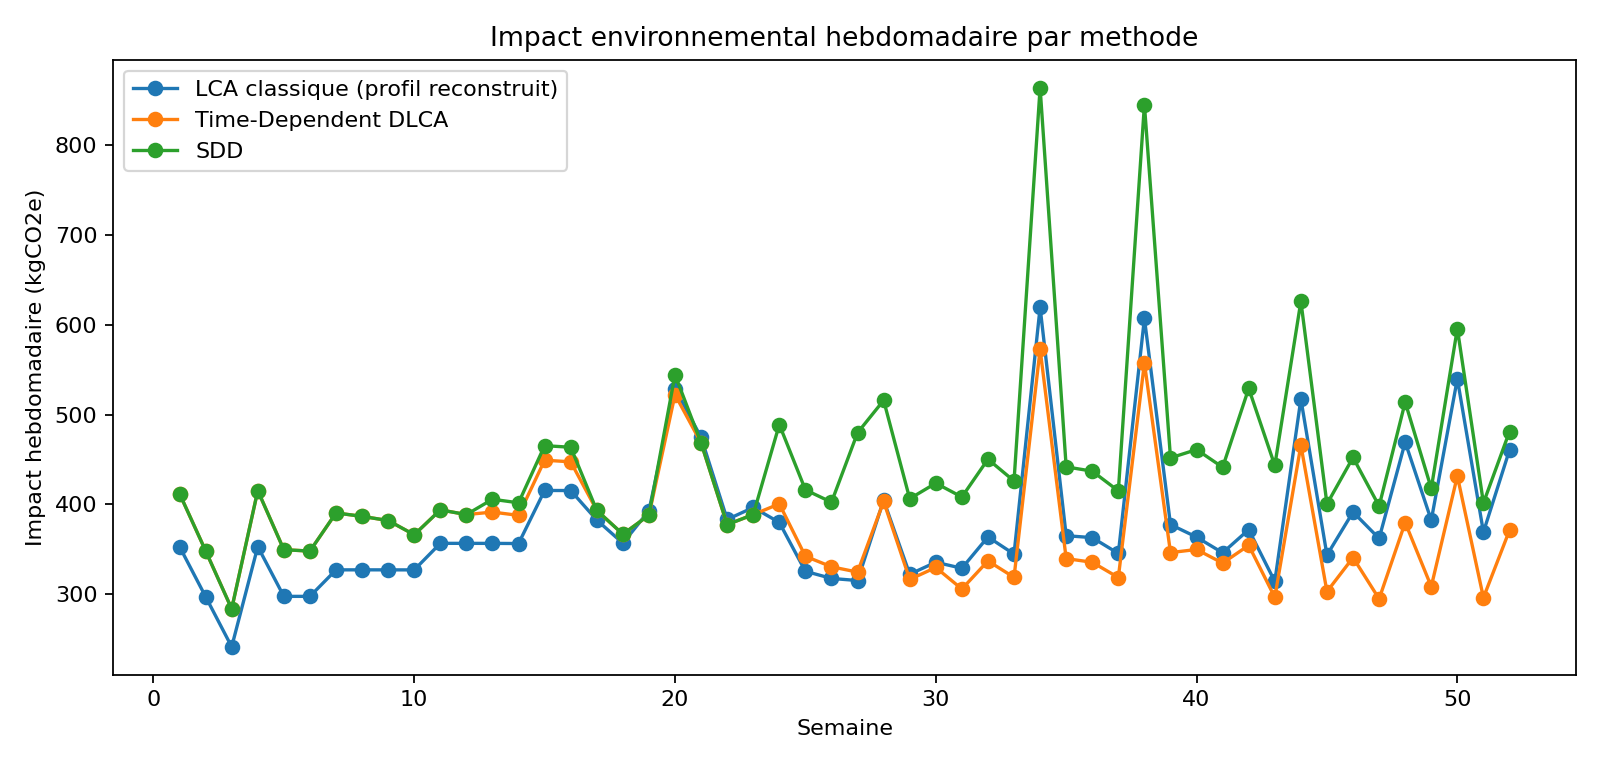

In [4]:
show_image('poc_weekly_impact_comparison.png', width=950)

**Lecture attendue**

- La `LCA classique` agrege les flux et les facteurs sur l'horizon d'etude. Elle ecrase donc le decalage entre une production realisee pendant des semaines tres carbonees et des expeditions qui interviennent plus tard.
- La `Time-Dependent DLCA` conserve une resolution hebdomadaire des flux `q_i(t)` et du facteur reseau `CF_grid(t)`. Dans ce POC, c'est principalement cette dependance temporelle explicite qui la distingue de la `LCA classique`.
- Le `SDD` part de la meme chronologie hebdomadaire, mais il ajoute des effets qui dependent de l'etat operationnel interne : recours au `backup`, transport aerien, surcharge productive, rebut.
- Le profil hebdomadaire attribue a la `LCA classique` doit etre interprete comme une **repartition reconstruite** du total classique sur les semaines observees. Il sert a comparer les formes temporelles, pas a redefinir la nature stationnaire de l'ACV classique.
- Le message scientifique du graphe est donc double : le **temps** corrige deja une partie du biais, et l'**etat** corrige le reste.


### Que signifie exactement la `Time-Dependent DLCA` dans ce POC ?

Il faut ici etre rigoureux sur les definitions.

Formellement :
- `LCA classique` : `I = somme_i q_i * CF_i`
- `Time-Dependent DLCA` : `I = somme_t somme_i q_i(t) * CF_i(t)`
- `SDD` : `x_(t+1) = f(x_t, u_t, w_t)` puis `I_t = g(x_t, q_t, CF_t)`

Dans ce POC, l'implementation exacte est la suivante.

1. **Simulation operationnelle commune**

Le modele de supply chain simule d'abord une trajectoire hebdomadaire unique : stocks, pipeline, backlog, production, expeditions, mode aval. Cette trajectoire fournit les flux observes `q_i(t)`.

2. **LCA classique**

La `LCA classique` reutilise cette trajectoire uniquement pour construire des **agregats** sur l'horizon :
- production utile totale ;
- expeditions totales ;
- stock moyen MP/PF ;
- facteur reseau moyen.

Elle impose ensuite des hypotheses stationnaires :
- matiere principale uniquement ;
- transport aval nominal par camion ;
- intensite energetique nominale ;
- pas de charge explicite du rebut.

3. **Time-Dependent DLCA**

La `Time-Dependent DLCA` utilise la meme trajectoire, mais garde la resolution hebdomadaire des flux :
- production utile hebdomadaire ;
- expeditions hebdomadaires ;
- stocks hebdomadaires ;
- facteur reseau hebdomadaire `CF_grid(t)`.

Dans ce POC, elle reste volontairement **nominale** sur les regimes operationnels :
- pas de facteur specifique au `backup` ;
- pas de bascule vers l'aerien ;
- pas de rebut explicite ;
- pas d'intensite energetique dependante de la surcharge.

Autrement dit, elle est bien `time-dependent`, mais pas encore `state-dependent`.

4. **State-Dependent Dynamic LCA**

Le `SDD` prend la meme base temporelle, puis rend l'inventaire et/ou la caracterisation dependants de l'etat `x_t` :
- facteur matiere et transport amont differents selon la provenance `main` / `backup` ;
- transport aval camion ou aerien selon le backlog ;
- intensite energetique dependante de l'utilisation de capacite ;
- charge explicite du rebut.

5. **Point de vigilance de lecture**

Quand un graphe montre une courbe hebdomadaire pour la `LCA classique`, il s'agit d'un **profil reconstruit sous hypotheses stationnaires**. Le total classique est rigoureux ; la desagregation hebdomadaire n'est qu'un outil de visualisation.

6. **Verification methodologique minimale**

Le script exporte aussi un tableau de controle (`poc_method_sanity_checks.csv`) qui verifie notamment :
- que la `Time-Dependent DLCA` differe bien de la `LCA classique` sur le scenario annuel commun ;
- que `SDD >= Time-Dependent DLCA` sur ce meme scenario ;
- que le gel du facteur reseau reduit l'ecart entre `LCA classique` et `Time-Dependent DLCA`.

Le point important est methodologique : la `Time-Dependent DLCA` n'est pas contrainte a etre toujours plus elevee que la `LCA classique`. Elle peut etre plus haute ou plus basse selon la distribution temporelle des flux et des facteurs. Ce que le POC verifie, c'est qu'elle repond bien a cette temporalite explicite.


## 2. Pourquoi le SDD trouve plus d'impact

Le deuxieme message essentiel est causal : le `SDD` ne donne pas seulement un chiffre plus grand, il montre **pourquoi** l'impact augmente.

Le bon graphique est celui qui met face a face :
- ce que voit la `LCA classique` ;
- ce que voit la `time-dependent DLCA` ;
- ce que le `SDD` ajoute.

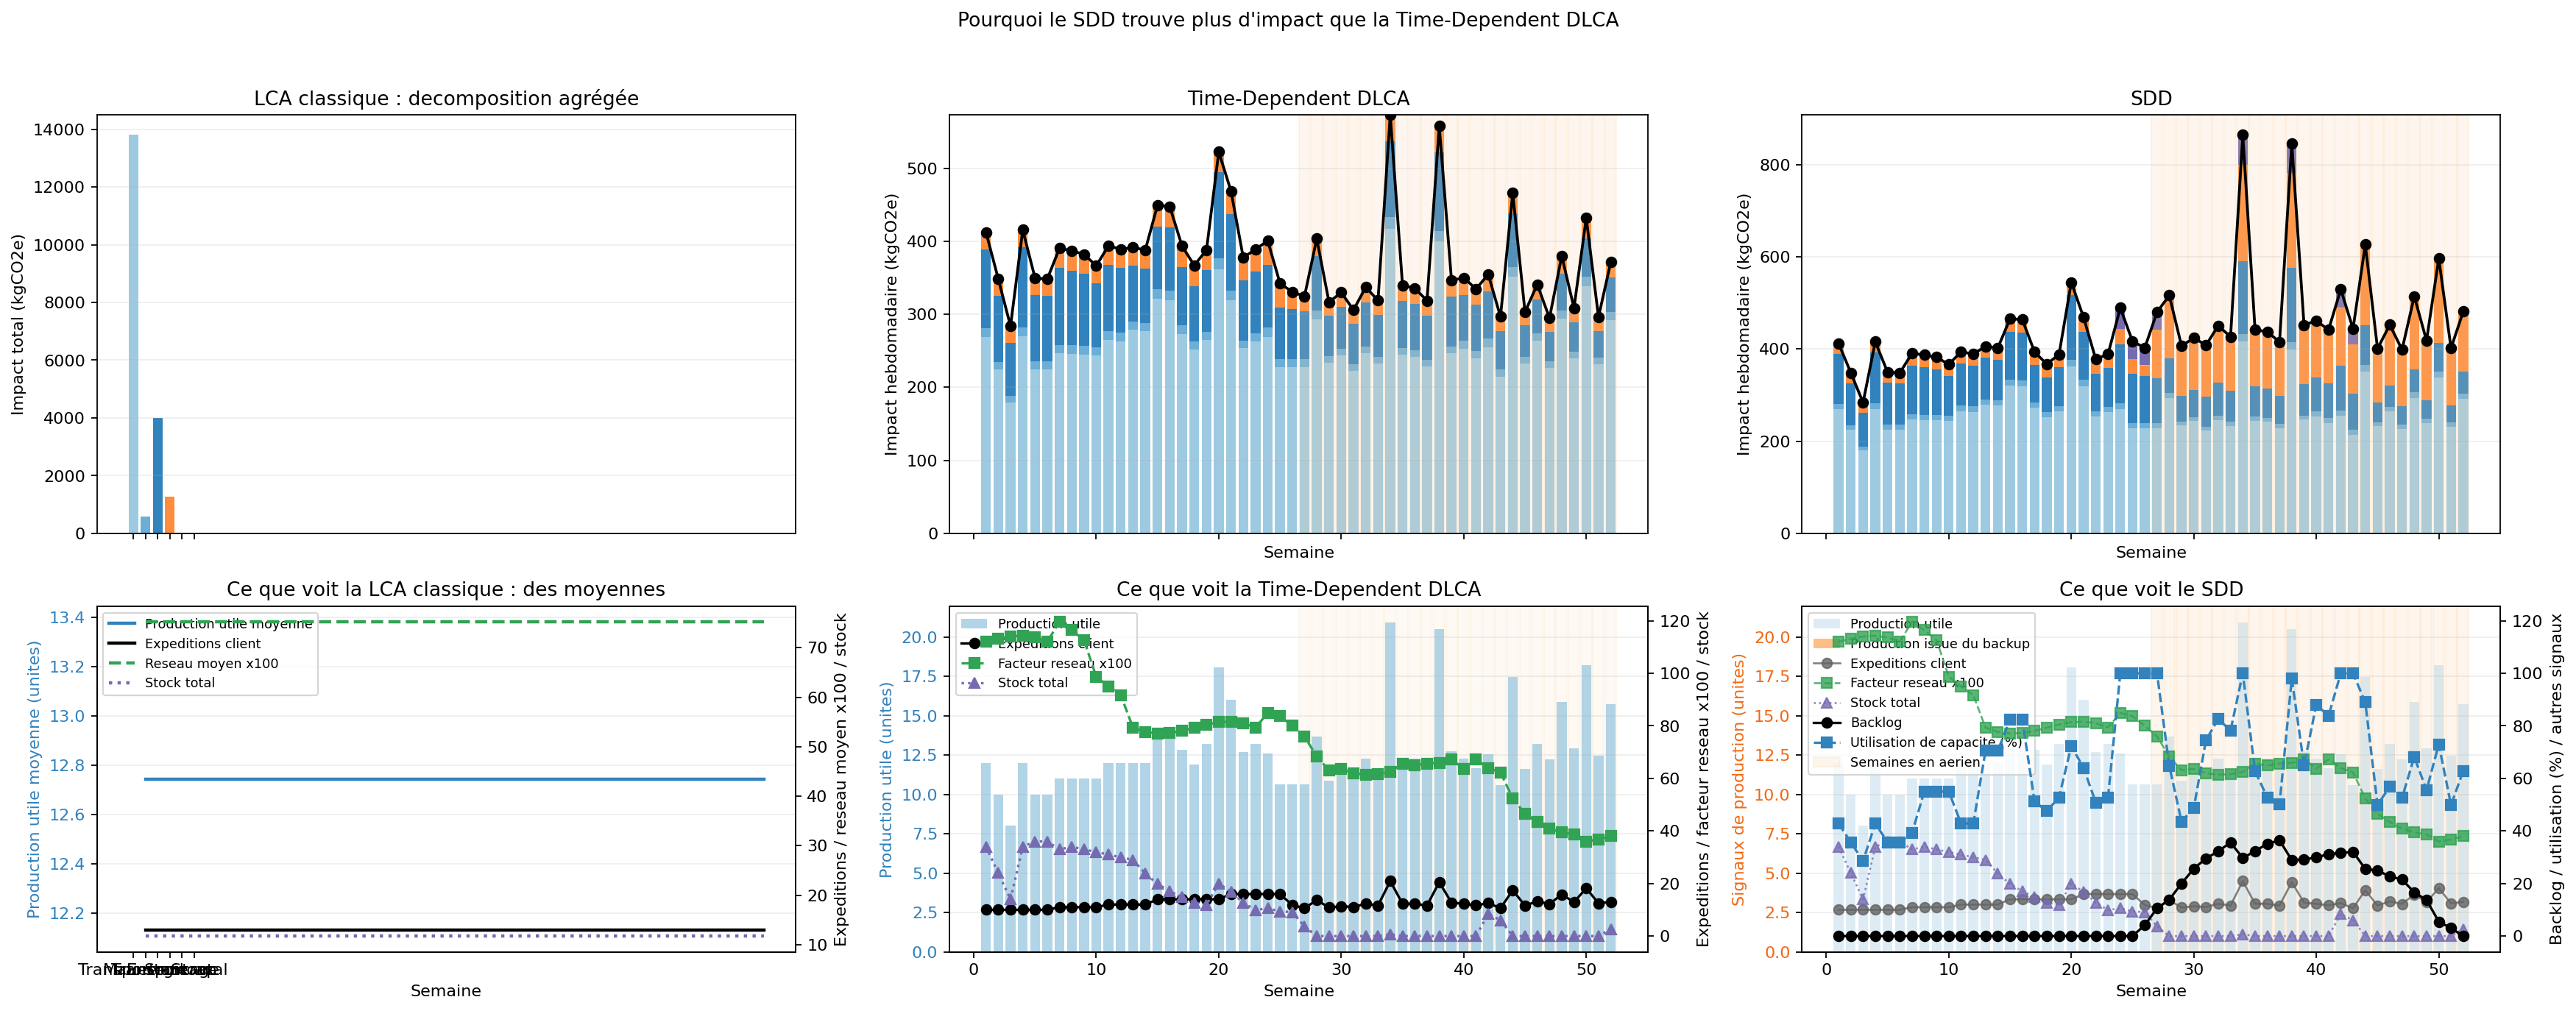

In [5]:
show_image('poc_sdd_gap_drivers.png', width=1250)

**Lecture attendue**

Ce graphe doit etre lu comme un graphe de causalite operationnelle.

- En haut, on compare la forme de representation de chaque methode :
  - `LCA classique` : decomposition agregee ;
  - `Time-Dependent DLCA` : impacts hebdomadaires dans le temps ;
  - `SDD` : meme logique temporelle, enrichie par des variables d'etat et des changements de regime.
- En bas, on compare ce que chaque methode mobilise effectivement pour interpreter la situation :
  - la `LCA classique` raisonne a partir d'agregats ou de moyennes ;
  - la `Time-Dependent DLCA` voit les evolutions hebdomadaires des flux et des facteurs temporels explicites ;
  - le `SDD` voit en plus les variables d'etat qui gouvernent les regimes operationnels.
- Il faut insister sur le fait que les trois methodes observent ici une **meme trajectoire simulee**. La difference ne vient donc pas d'un changement du systeme physique, mais du niveau de finesse avec lequel l'impact environnemental est attribue.
- Le panel `LCA classique` ne doit pas etre surinterprete temporellement : le haut montre une decomposition agregee, et le bas des moyennes ou profils reconstruits a partir d'hypotheses stationnaires.
- Le panel `Time-Dependent DLCA` montre deja un gain important : il respecte la sequence temporelle des flux.
- Le panel `SDD` montre pourquoi cela ne suffit pas encore lorsque les impacts changent de nature avec l'etat du systeme.


## 3. Ce que voit chaque methode

Ce graphe sert a poser la difference methodologique de facon simple :
- `LCA classique` : representation agregee et stationnaire ;
- `Time-Dependent DLCA` : representation temporelle des flux et des facteurs exogenes ;
- `SDD` : representation temporelle enrichie par les etats internes de la supply chain.

L'interet du graphe est qu'il montre une progression logique :
- d'abord un systeme moyen ;
- puis un systeme date ;
- enfin un systeme date **et** state-dependent.


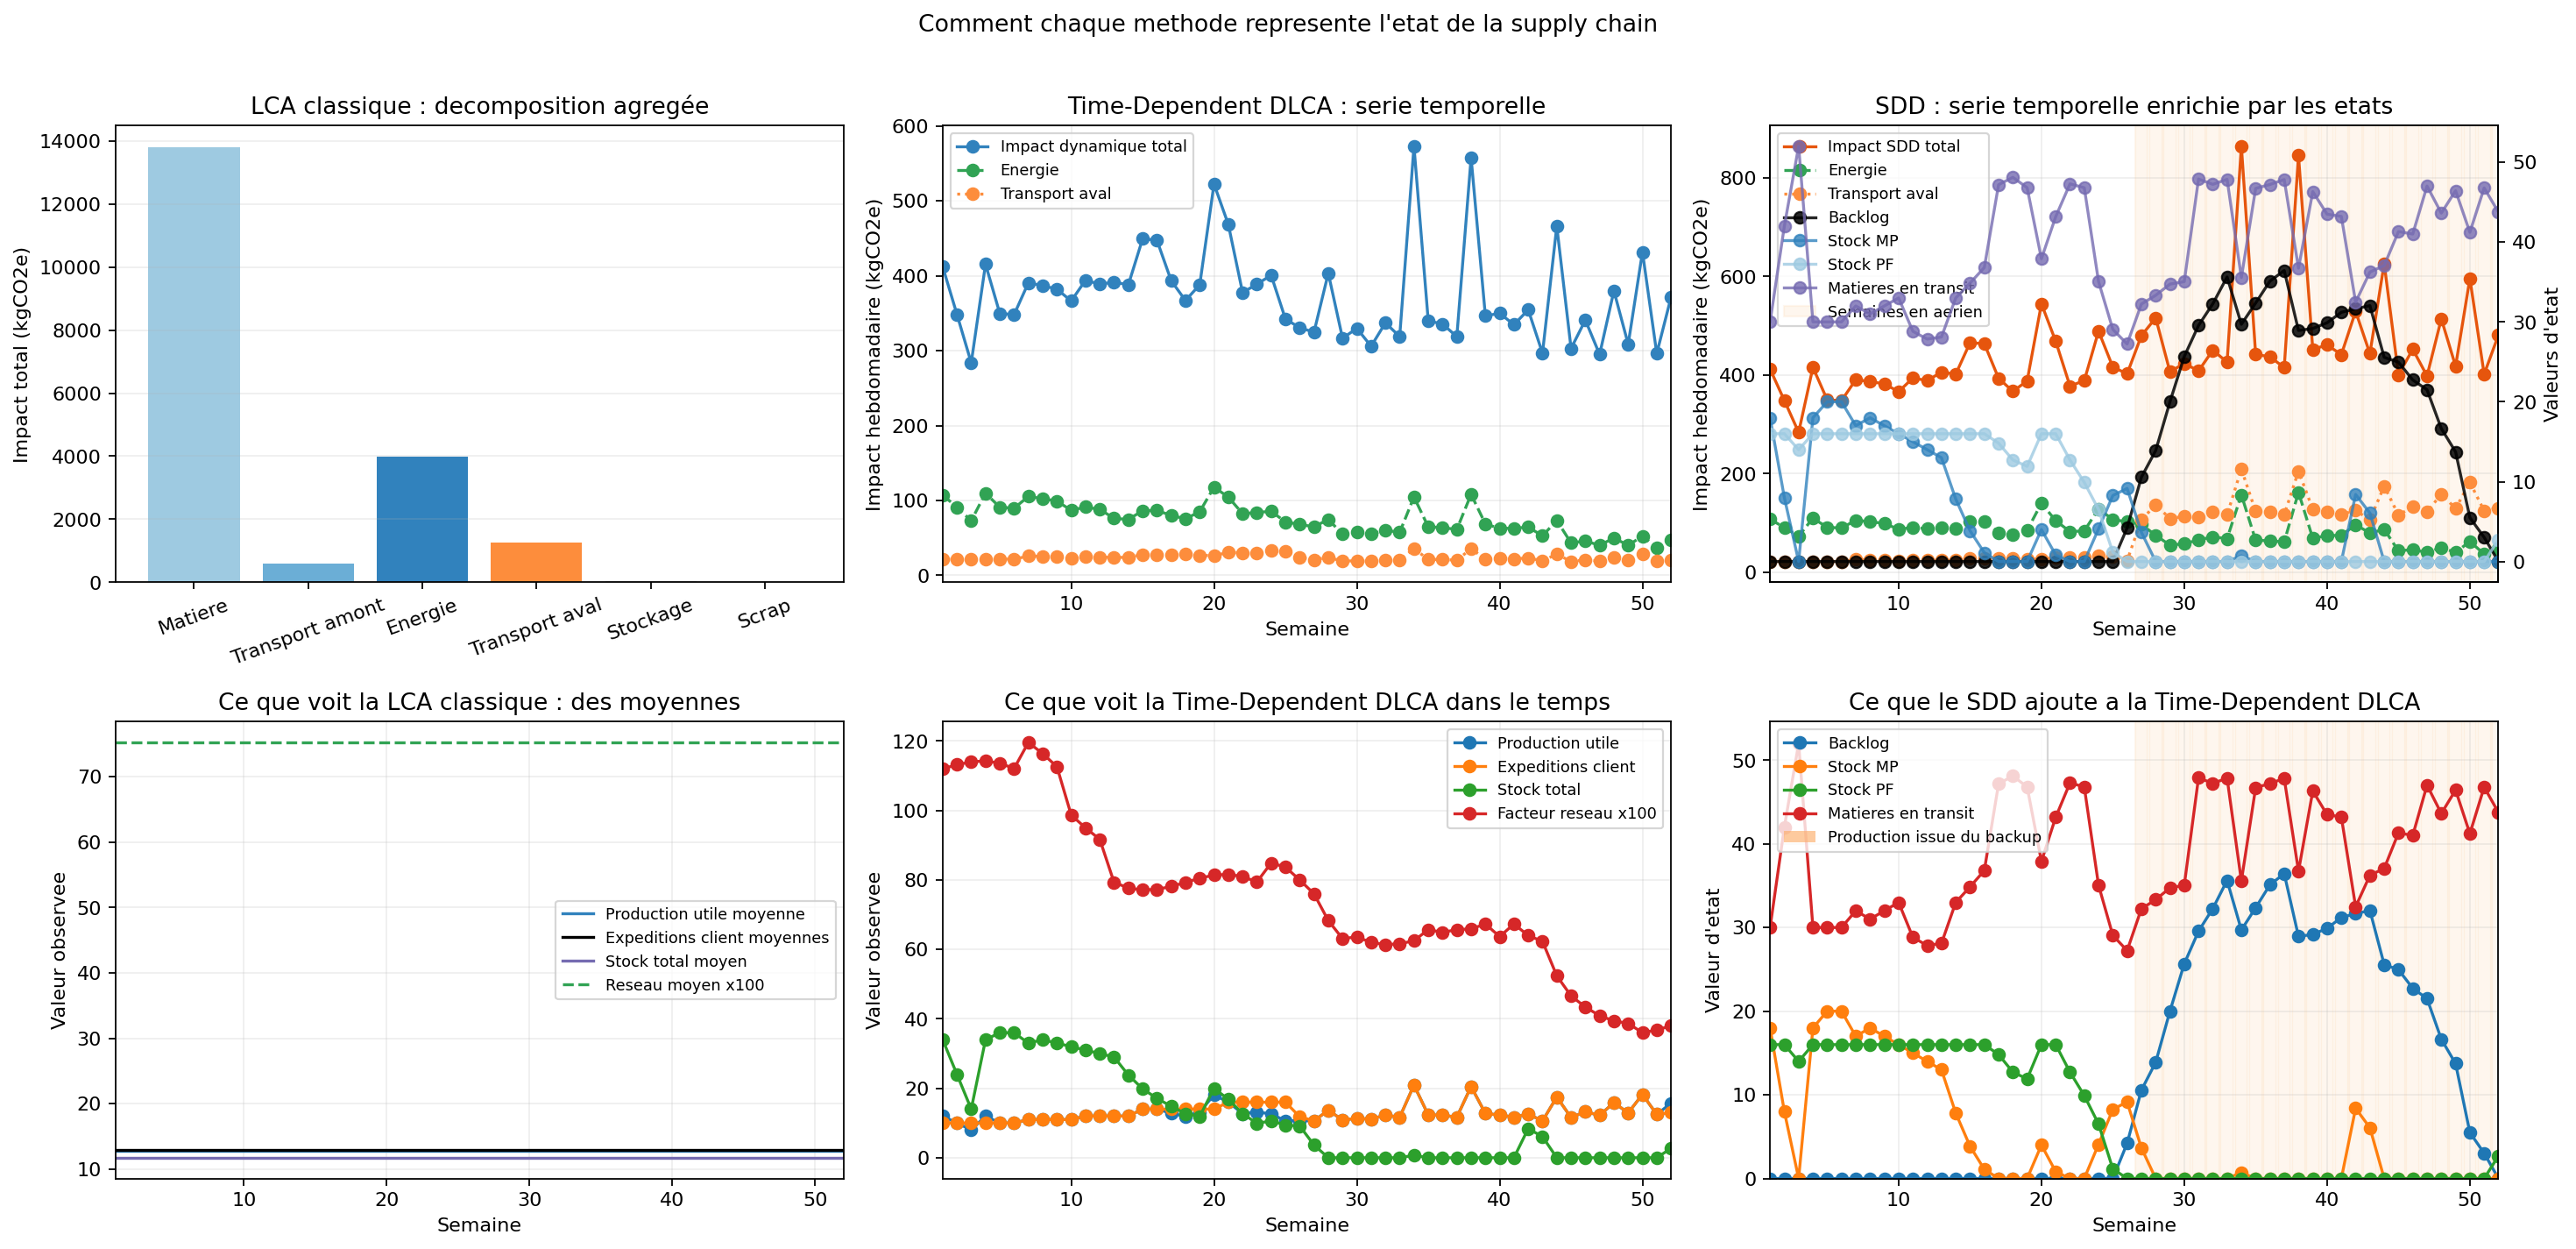

In [6]:
show_image('poc_state_space_method_comparison.png', width=1250)

**Lecture attendue**

Ce graphe ne doit pas etre compris comme un simple comparatif visuel de courbes, mais comme une comparaison de **niveaux de representation du systeme**.

- La `LCA classique` represente la supply chain comme un systeme moyen. Elle est adaptee a une lecture agregee, stable, peu sensible aux transitoires. Dans ce notebook, son profil hebdomadaire n'est utilise qu'a titre de reconstruction visuelle.
- La `Time-Dependent DLCA` ajoute la date des flux. Elle peut donc distinguer une production realisee pendant des semaines carbonees d'une production realisee pendant des semaines plus sobres, meme si le volume total reste identique.
- Le `SDD` ajoute des variables endogenes qui n'appartiennent pas a une DLCA standard : backlog, stock MP, stock PF, matieres en transit, production issue du `backup`, activation de l'aerien.
- La question scientifique cle n'est donc pas seulement : "quand les flux ont-ils lieu ?" mais aussi : "dans quel **etat operationnel** le systeme se trouvait-il quand ils ont eu lieu ?"
- C'est ce passage de `I = f(q(t), CF(t))` a `I = f(q(t, x_t), CF(t, x_t))` qui justifie l'existence du `SDD` comme cadre distinct.


## 4. Ce que cela change pour comparer des politiques

Une fois la logique comprise sur le cas de base, il faut montrer que l'ecart reste present quand on compare des politiques de pilotage.

Le graphe suivant est tres utile parce qu'il rend visible, pour chaque politique, le saut entre `time-dependent DLCA` et `SDD`.

In [7]:
cols = [
    'policy_label',
    'same_week_service_pct',
    'total_cost',
    'classical_total_kgCO2e',
    'dynamic_total_kgCO2e',
    'sddlca_total_kgCO2e',
]
display(decision_summary[cols].round(2))

,policy_label,same_week_service_pct,total_cost,classical_total_kgCO2e,dynamic_total_kgCO2e,sddlca_total_kgCO2e
0,Reference,93.25,57053.41,19673.48,19457.82,23169.80
1,Backup anticipe,93.25,57053.41,19673.48,19457.82,23169.80
2,Stock tampon,98.42,43496.93,20118.31,20022.80,21968.63
3,Discipline carbone,91.19,61978.37,19324.08,19079.28,22802.94
4,Service prioritaire,97.29,45756.57,20075.52,19944.45,22514.27


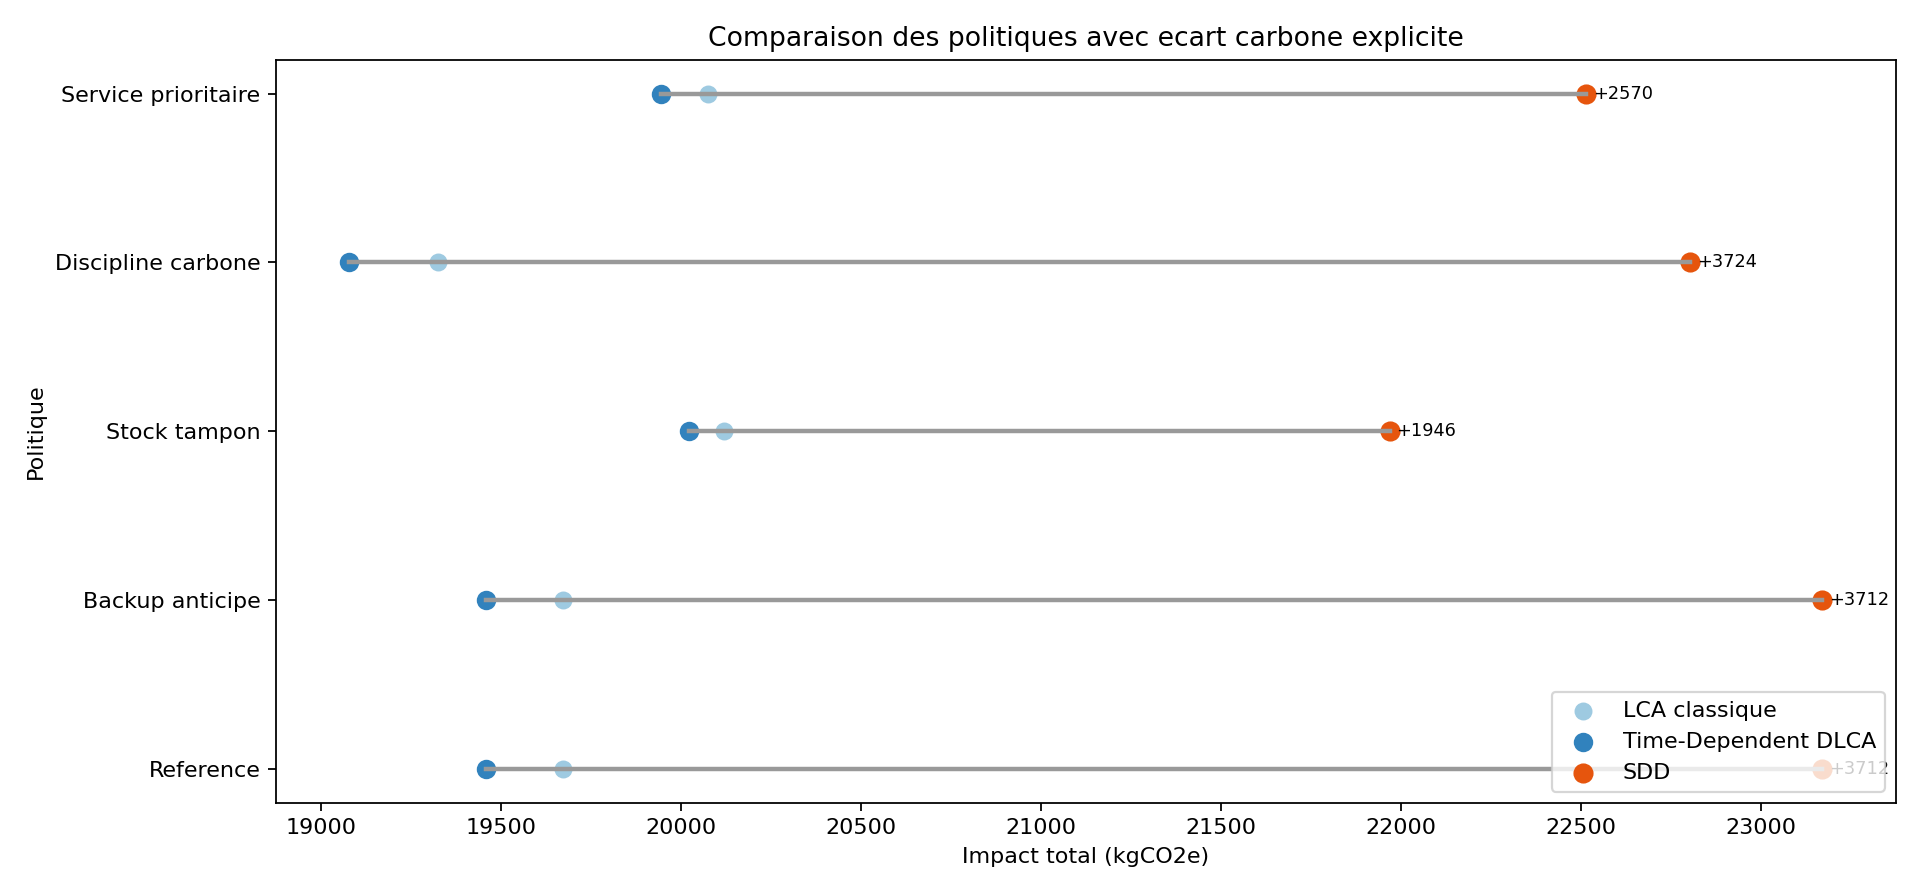

In [8]:
show_image('poc_policy_method_gap.png', width=1150)

## 5. Ce que cela change pour la decision

Le dernier message du coeur de presentation est que le `SDD` ne sert pas seulement a mieux mesurer : il sert a **mieux arbitrer** entre service, cout et carbone.

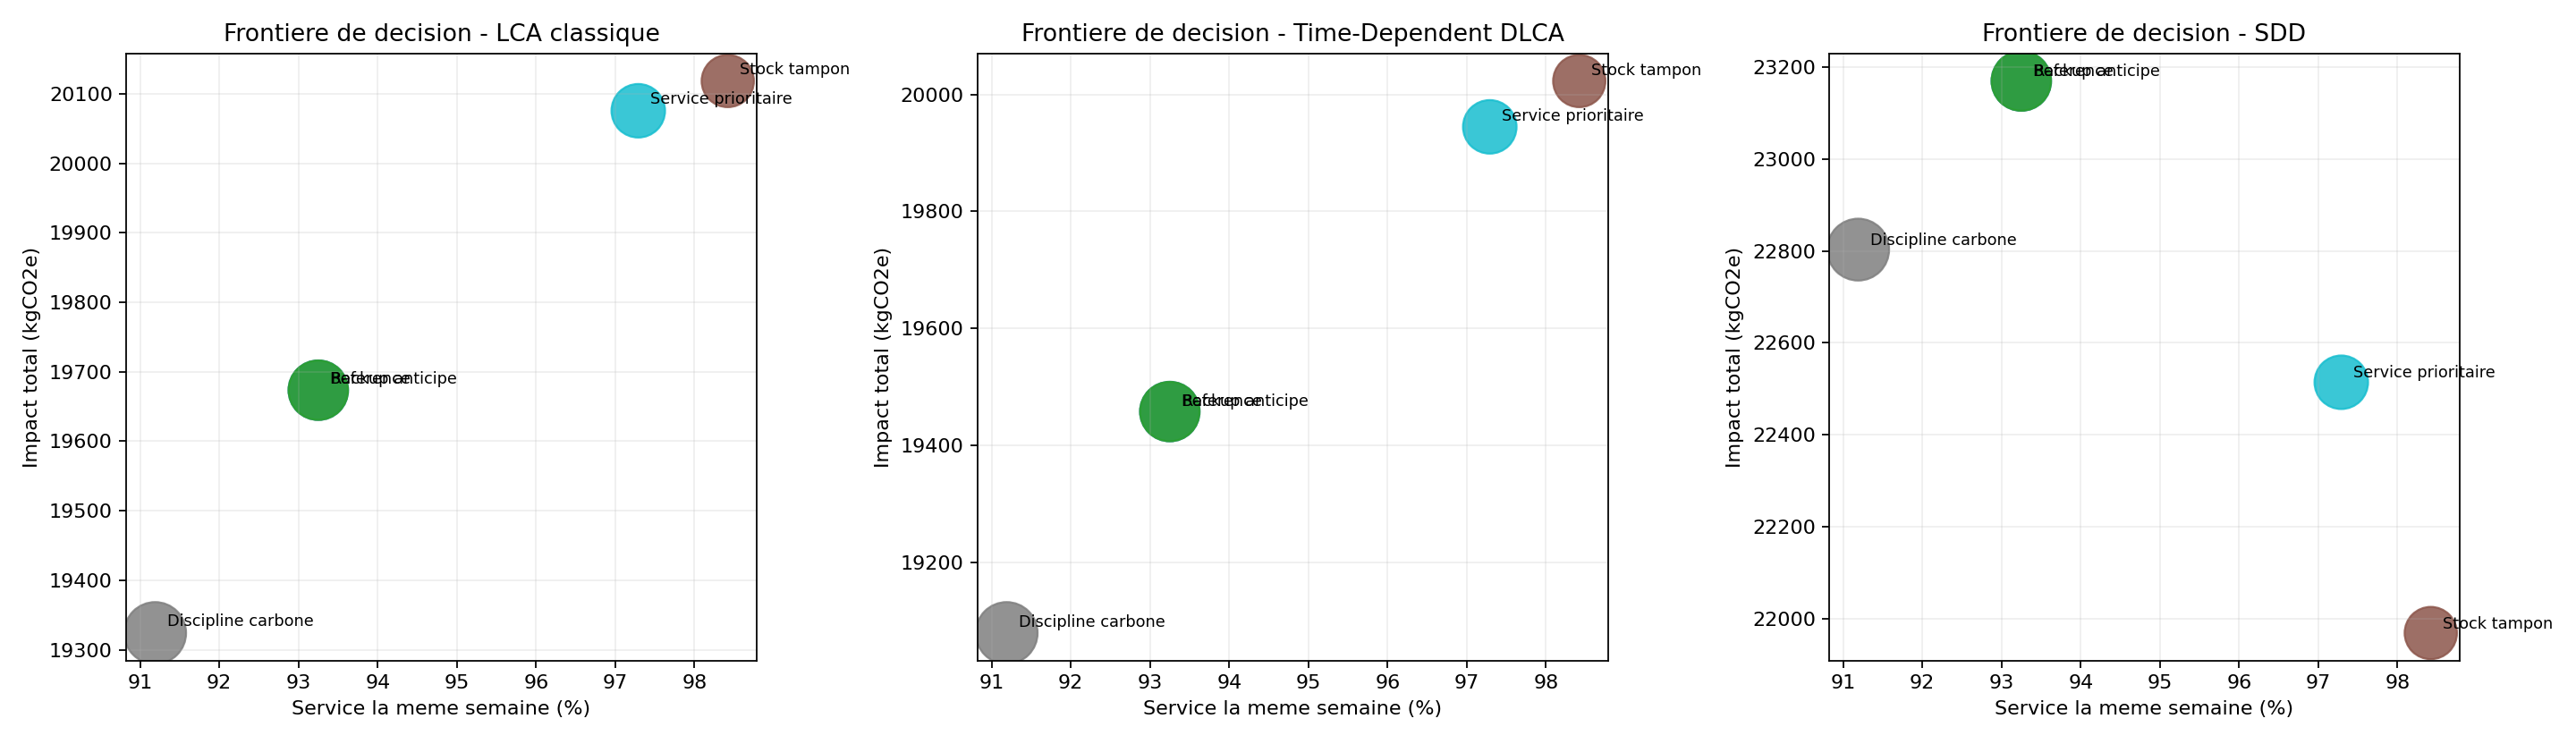

In [9]:
show_image('poc_policy_decision_frontier.png', width=1100)

**Lecture attendue**

- La frontiere de decision ne repond pas a une question purement carbone ; elle repond a une question de **pilotage**.
- L'axe horizontal mesure le service, l'axe vertical le carbone, et la taille des bulles represente le cout total.
- Une politique qui semble acceptable sous `LCA classique` ou sous `time-dependent DLCA` peut devenir moins desirable sous `SDD` si elle repose en pratique sur plus d'aerien, plus de backup ou plus de tension operationnelle.

Questions auxquelles ce graphe repond :
- **La politique la plus service est-elle aussi la plus sobre ?**
  Reponse : pas necessairement.
- **Le `SDD` change-t-il seulement la quantification ou aussi le classement ?**
  Reponse : il peut changer le classement et donc l'arbitrage.
- **Pourquoi ce graphe est-il important pour l'operationnel ?**
  Reponse : parce qu'il reconnecte la question carbone avec les questions de service et de cout, qui sont les vraies contraintes de pilotage.



## Conclusion du coeur de presentation

Le recit que je presenterais est le suivant :

1. `LCA classique` et `Time-Dependent DLCA` ne racontent deja plus la meme histoire sur ce cas, parce que la chronologie des flux compte.
2. Le `SDD` revele un sur-impact supplementaire important.
3. Ce sur-impact n'est pas abstrait : il vient de regimes operationnels identifiables.
4. La comparaison de politiques change lorsqu'on prend ces regimes en compte.
5. L'apport du `SDD` est donc a la fois descriptif, explicatif et decisionnel.

La nuance methodologique importante a rappeler a l'oral est la suivante :
- les trois methodes partent ici d'une **meme simulation operationnelle** ;
- la `LCA classique` l'agrege ;
- la `Time-Dependent DLCA` la date ;
- le `SDD` la date **et** la conditionne a l'etat interne du systeme.

C'est cette hierarchie qu'il faut faire comprendre pour eviter de donner l'impression que la `Time-Dependent DLCA` ou le `SDD` changent le systeme physique lui-meme. Ils changent la facon dont l'impact est reconstruit a partir de ce systeme.


# Annexes

Les annexes ci-dessous permettent de completer la demonstration pour un public plus technique, tout en restant lisibles pour l'operationnel.

## Annexe A. Decomposition des impacts par politique

Ce graphe sert a montrer quels postes d'impact deviennent dominants selon la politique retenue.

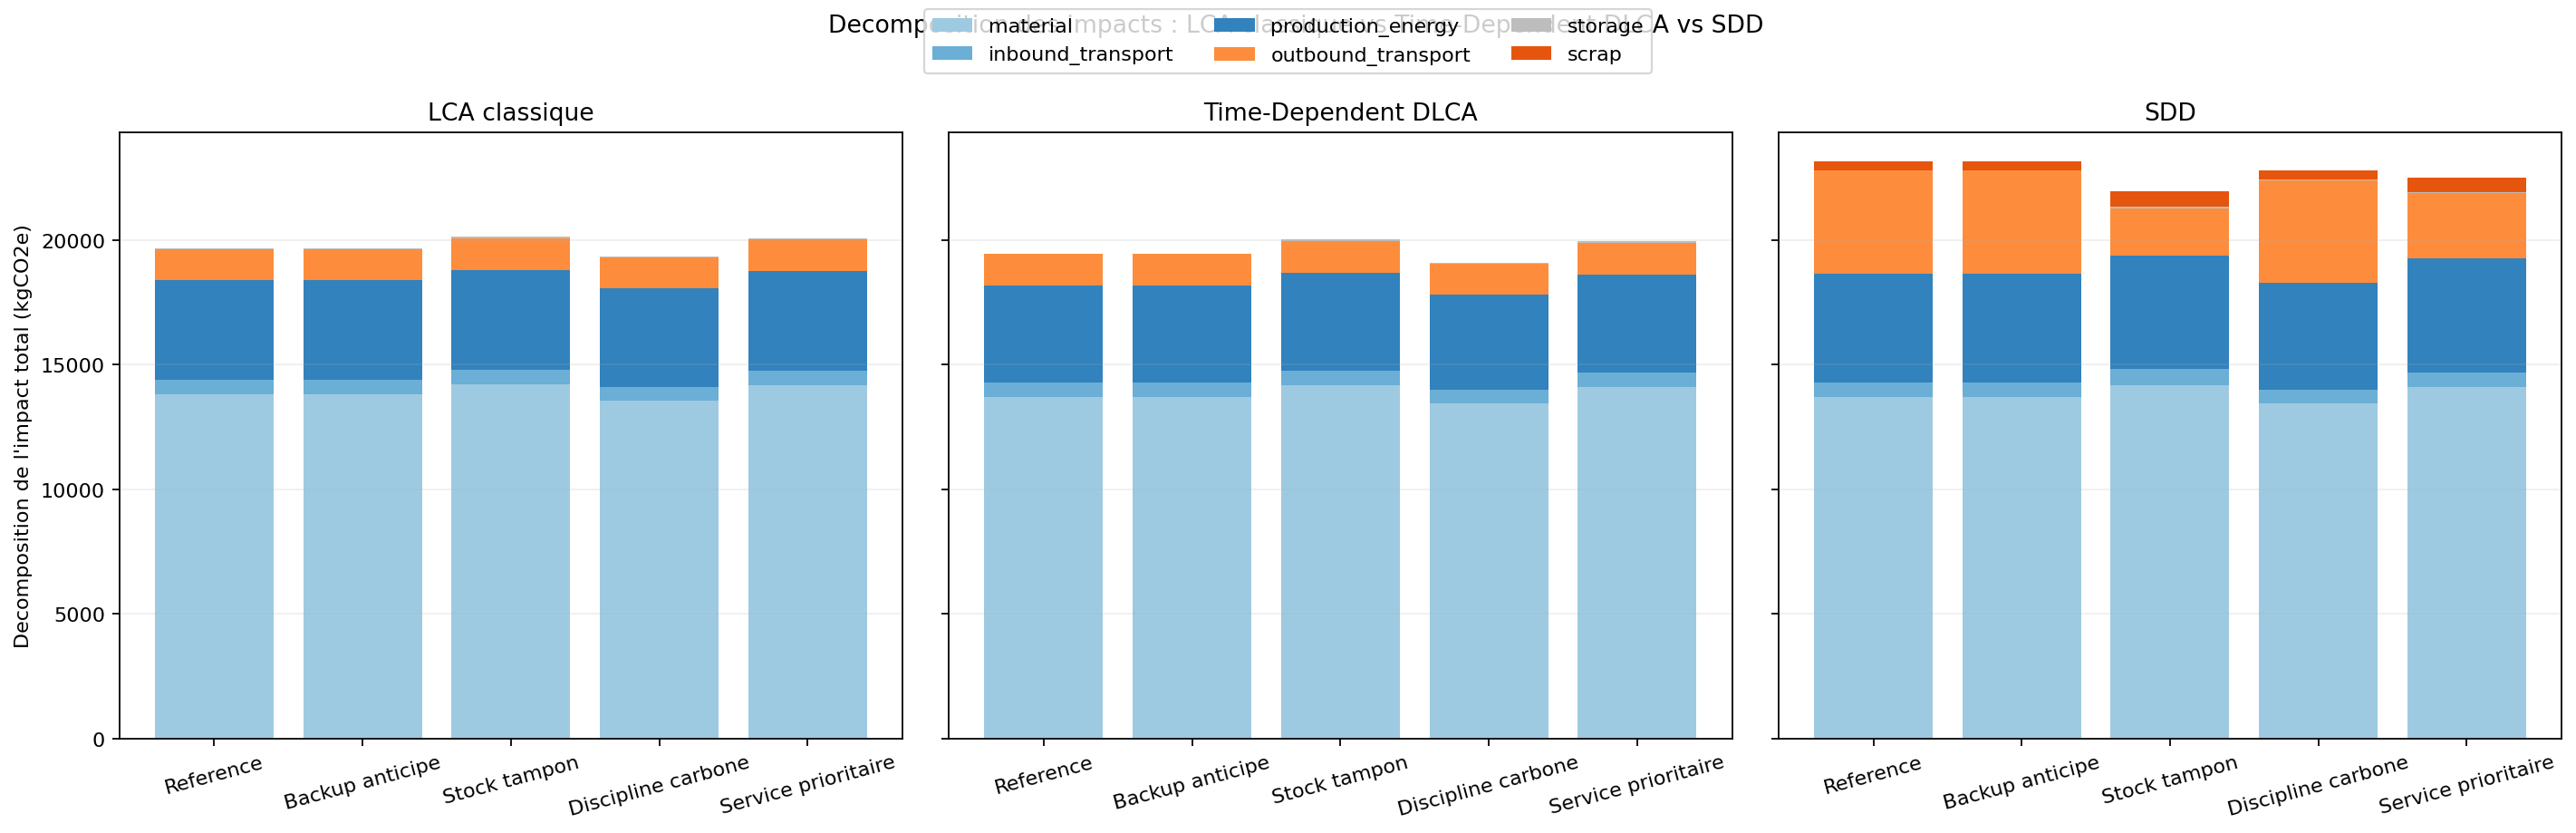

In [10]:
show_image('poc_policy_causal_attribution.png', width=1150)

### Focus scientifique : pourquoi le `scrap` ressort davantage en `SDD` ?

Le `scrap` est un point qui suscite souvent une question immediate : pourquoi est-il presque invisible dans les autres methodes alors qu'il devient visible en `SDD` ?

La reponse est structurelle :
- dans ce POC, la `LCA classique` et la `time-dependent DLCA` ne portent pas explicitement la charge carbone du rebut ;
- le `SDD` attribue au rebut la matiere, le transport amont et l'energie deja engages pour produire une unite qui ne sera jamais livree.

Scientifiquement, cela revient a dire que le `SDD` ne comptabilise pas seulement ce qui sort utilement du systeme, mais aussi ce qui a ete **consomme puis perdu**.

Operationnellement, cela veut dire que :
- une chaine sous tension produit non seulement moins bien ;
- elle detruit aussi davantage de valeur materielle et energetique ;
- cette destruction devient un poste carbone visible.

Question pertinente :
- **Pourquoi le `scrap` augmente-t-il souvent en meme temps que le `backup` ou l'aerien ?**
  Parce que ces signaux sont tous les symptomes d'un regime degrade : supply sous contrainte, capacite tendue, pilotage en urgence, moindre robustesse du systeme.


## Annexe B. Tracabilite de la production

Cette annexe sert a expliciter **d'ou viennent physiquement les produits finis utiles** et a quel moment le systeme commence a dependre du `backup`.

Comment lire le graphe :
- les barres empilees representent la `production utile`, c'est-a-dire les produits finis fabriques sans rebut pendant la semaine ;
- la decomposition des barres se fait par provenance : source principale versus source de secours ;
- la courbe noire represente le `backlog`, donc la demande non servie accumulee.

Ce que ce graphe montre scientifiquement :
- la perturbation ne change pas seulement le volume produit ; elle change aussi la **provenance** de ce qui est produit ;
- cette provenance compte pour le carbone, parce que le `backup` a dans ce POC des facteurs d'impact plus eleves ;
- la presence simultanee d'une hausse du `backlog` et d'une augmentation de la part `backup` signale une reconfiguration degradee de la chaine.

Questions pertinentes et reponses :
- **La production utile est-elle la meme chose que le stock de produits finis ?**
  Non. La production utile est un **flux** hebdomadaire ; le stock PF est un **stock** en fin de semaine.
- **Pourquoi le graphe montre-t-il la production utile et pas directement les expeditions client ?**
  Parce qu'il cherche a documenter l'origine de ce qui a ete produit, avant meme la question de l'expedition.
- **Pourquoi la provenance est-elle importante pour le `SDD` ?**
  Parce que le `SDD` ne calcule pas seulement des volumes : il attribue les impacts en tenant compte des regimes de sourcing et des conditions reelles de fonctionnement.


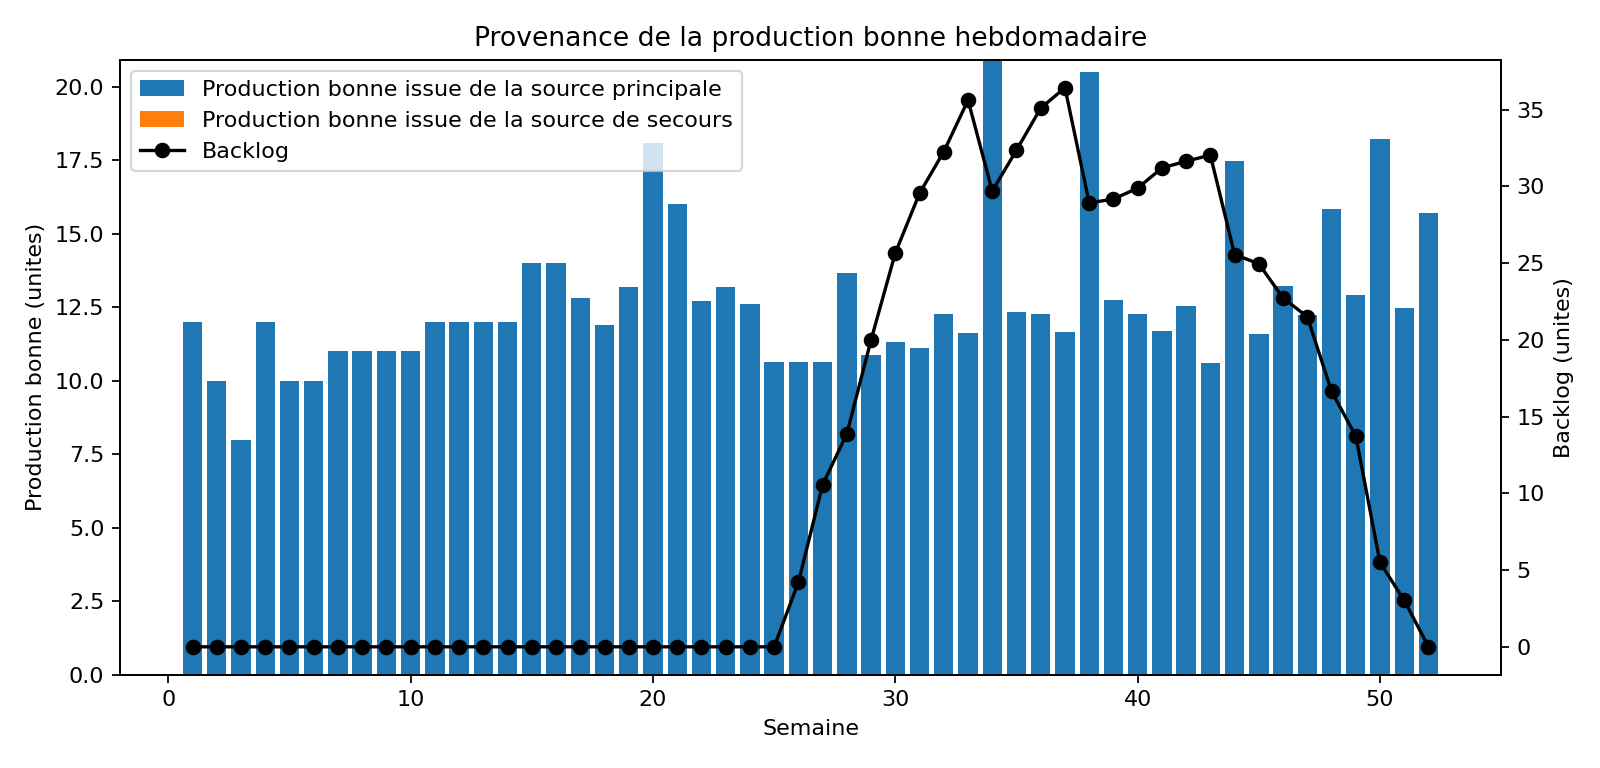

In [11]:
show_image('poc_source_traceability.png', width=1000)

## Annexe C. Projection d'etat du SDD

Cette annexe sert a expliciter la logique d'espace d'etat du POC.

Comment lire le graphe :
- Le panneau de gauche est une **projection reduite** de la trajectoire d'etat. On ne voit pas tout l'etat, mais un sous-ensemble interpretable : typiquement `stock MP`, `backlog` et `matieres en transit`.
- Le panneau de droite decompose des composantes d'etat au cours du temps : `backlog`, `stock MP`, `stock PF`, `matieres en transit`.

Pourquoi cette annexe est importante scientifiquement :
- elle montre que le `SDD` ne se contente pas d'ajouter une serie temporelle de plus ;
- elle montre que l'impact environnemental est relie a un **vecteur d'etat** qui evolue selon une dynamique propre ;
- elle permet donc de justifier la formulation `x_(t+1) = f(x_t, u_t, w_t)` utilisee dans le cadre methodologique.

Question a anticiper : **est-ce l'espace d'etat d'une methode LCA ou celui du systeme physique ?**

La bonne reponse est : c'est d'abord l'espace d'etat du **systeme operationnel**. Le `SDD` s'en sert ensuite pour conditionner l'inventaire et les facteurs environnementaux. Ce point est essentiel : la methode environnementale est couplee a une dynamique operationnelle, elle ne remplace pas cette dynamique.


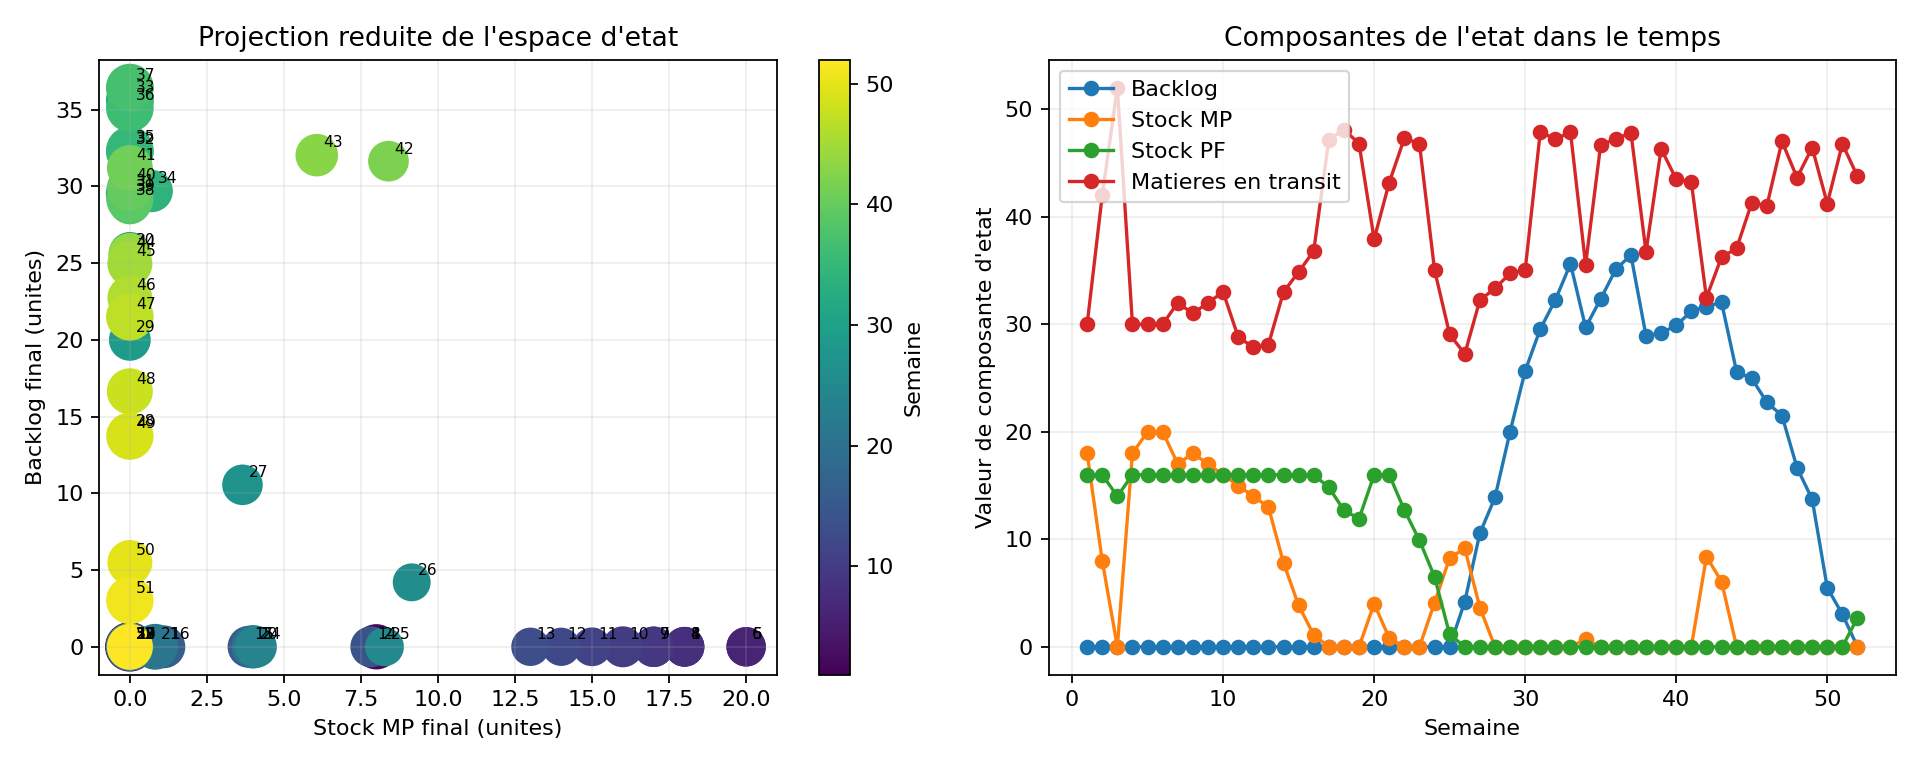

In [12]:
show_image('poc_state_space_projection.png', width=1050)

## Annexe E. Sensibilite

Cette annexe sert a verifier que le message du POC ne depend pas d'un seul jeu de parametres.

Comment lire le graphe :
- un panneau montre les expeditions client totales ;
- un panneau montre l'intensite carbone par unite expediee pour la `LCA classique` ;
- un panneau montre l'intensite carbone par unite expediee pour la `Time-Dependent DLCA` ;
- un panneau montre l'intensite carbone par unite expediee pour le `SDD`.

Questions a anticiper : **pourquoi les emissions absolues peuvent-elles baisser quand la disruption devient plus severe ?**

Parce qu'un systeme plus perturbe peut simplement produire et expedier moins. Une baisse d'emissions absolues ne signifie donc pas automatiquement une meilleure performance environnementale. Elle peut traduire une degradation du service et un effondrement des volumes.

C'est pour cela que ce graphe raisonne en **intensite par unite expediee**.

Ce que l'on doit retenir :
- la `LCA classique` reste la plus lisse, car elle ecrase les variations temporelles et les regimes ;
- la `Time-Dependent DLCA` est plus sensible a la structure temporelle du scenario ;
- le `SDD` reste le plus sensible aux regimes perturbes, car il internalise en plus le `backup`, l'aerien, la surcharge et le rebut.

Autrement dit, cette annexe ne sert pas seulement a dire que le `SDD` est plus eleve ; elle sert a montrer **pourquoi** son ecart reste robuste lorsque le scenario varie.


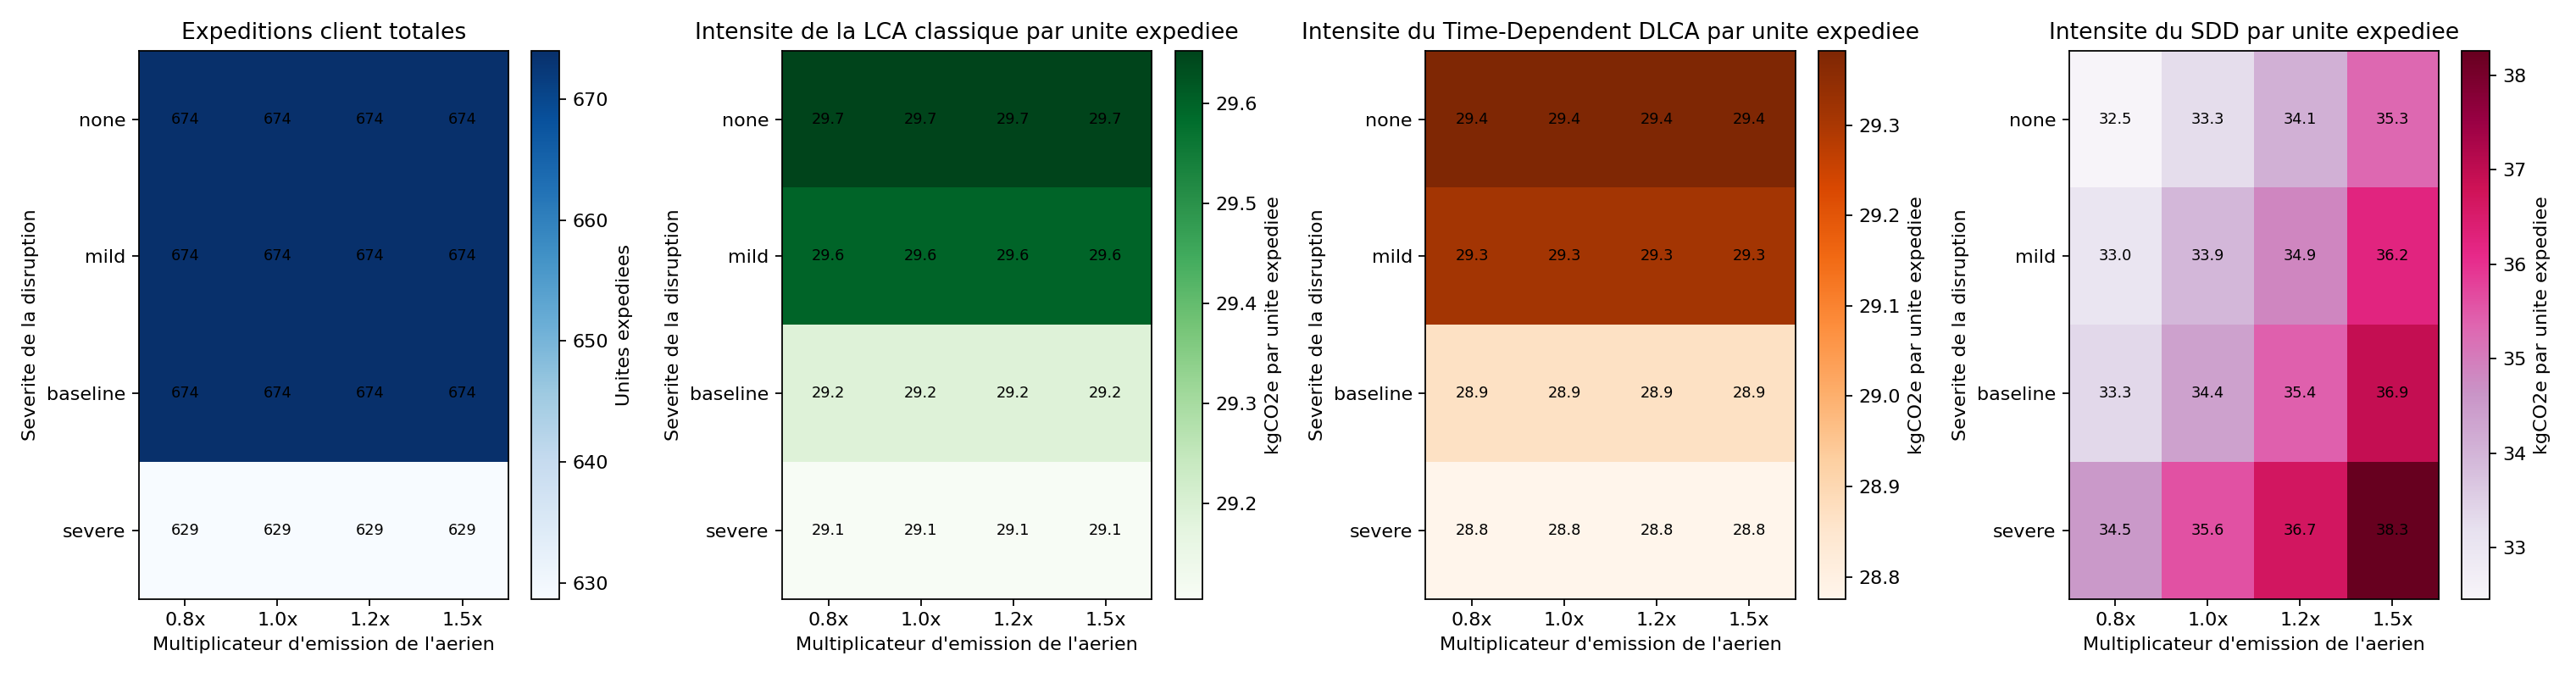

In [13]:
show_image('poc_sensitivity_volume_intensity.png', width=1150)

## Annexe G. Simulation annuelle commune : transition climatique et disruptions operationnelles

Cette annexe ne correspond plus a un scenario ajoute apres coup. Elle explicite au contraire la **simulation commune de reference** sur laquelle repose desormais le POC : une trajectoire annuelle unique ou interagissent evenements climatiques, evenements operationnels et retroactions d'une semaine sur l'autre.

La simulation combine simultanement :
- evolution du facteur reseau electrique ;
- chocs climatiques repetes sur la capacite de production ;
- penuries de matieres premieres principales ;
- retroactions operationnelles endogenes telles que maintenance corrective, congestion logistique, overtime et energie d'urgence ;
- recours au `backup` et au transport d'urgence quand le systeme bascule dans des regimes tendus ou de crise.

Le point important est donc le suivant : on ne compare plus un petit scenario de base a un scenario climatique separe. On observe une seule supply chain, suivie sur 52 semaines, dont les conditions climatiques degradent le fonctionnement et dont les reponses operationnelles amplifient ensuite certaines tensions.

### Ce qu'il faut regarder

- Le premier graphe montre les **pressions climatiques de base** et leur version **appliquee** apres retroaction operationnelle.
- Le second montre la **reponse endogene du systeme** : backlog, production issue du `backup`, expeditions aeriennes et regimes environnementaux.
- Le troisieme montre les **impacts cumules** selon les trois methodes sur cette meme trajectoire annuelle.

### Message scientifique

Cette simulation est utile parce qu'elle articule deux niveaux de causalite souvent dissocies :
- des evenements climatiques exogenes qui degradent capacite, disponibilite matiere et contexte energetique ;
- des evenements operationnels endogenes qui prolongent ou amplifient ensuite ces chocs, par exemple via maintenance corrective, congestion logistique, recours au `backup` ou transport aerien.

Il montre donc qu'un contexte énergétique plus favorable ne suffit pas à garantir une bonne performance environnementale si la supply chain bascule plus souvent dans des régimes tendus ou de crise.


In [14]:
pd.read_csv(CSV_DIR / 'poc_climate_transition_summary.csv')

,policy_name,policy_label,same_week_service_pct,fill_rate_pct,final_backlog_units,peak_backlog_units,total_cost,classical_total_kgCO2e,time_dependent_dlca_total_kgCO2e,dynamic_total_kgCO2e,sddlca_total_kgCO2e,hidden_carbon_vs_td_dlca,hidden_carbon_vs_dynamic,hidden_carbon_vs_classical
0,baseline,Reference,93.25,100.0,0.0,36.44,57053.41,19673.48,19457.82,19457.82,23169.8,3711.98,3711.98,3496.33


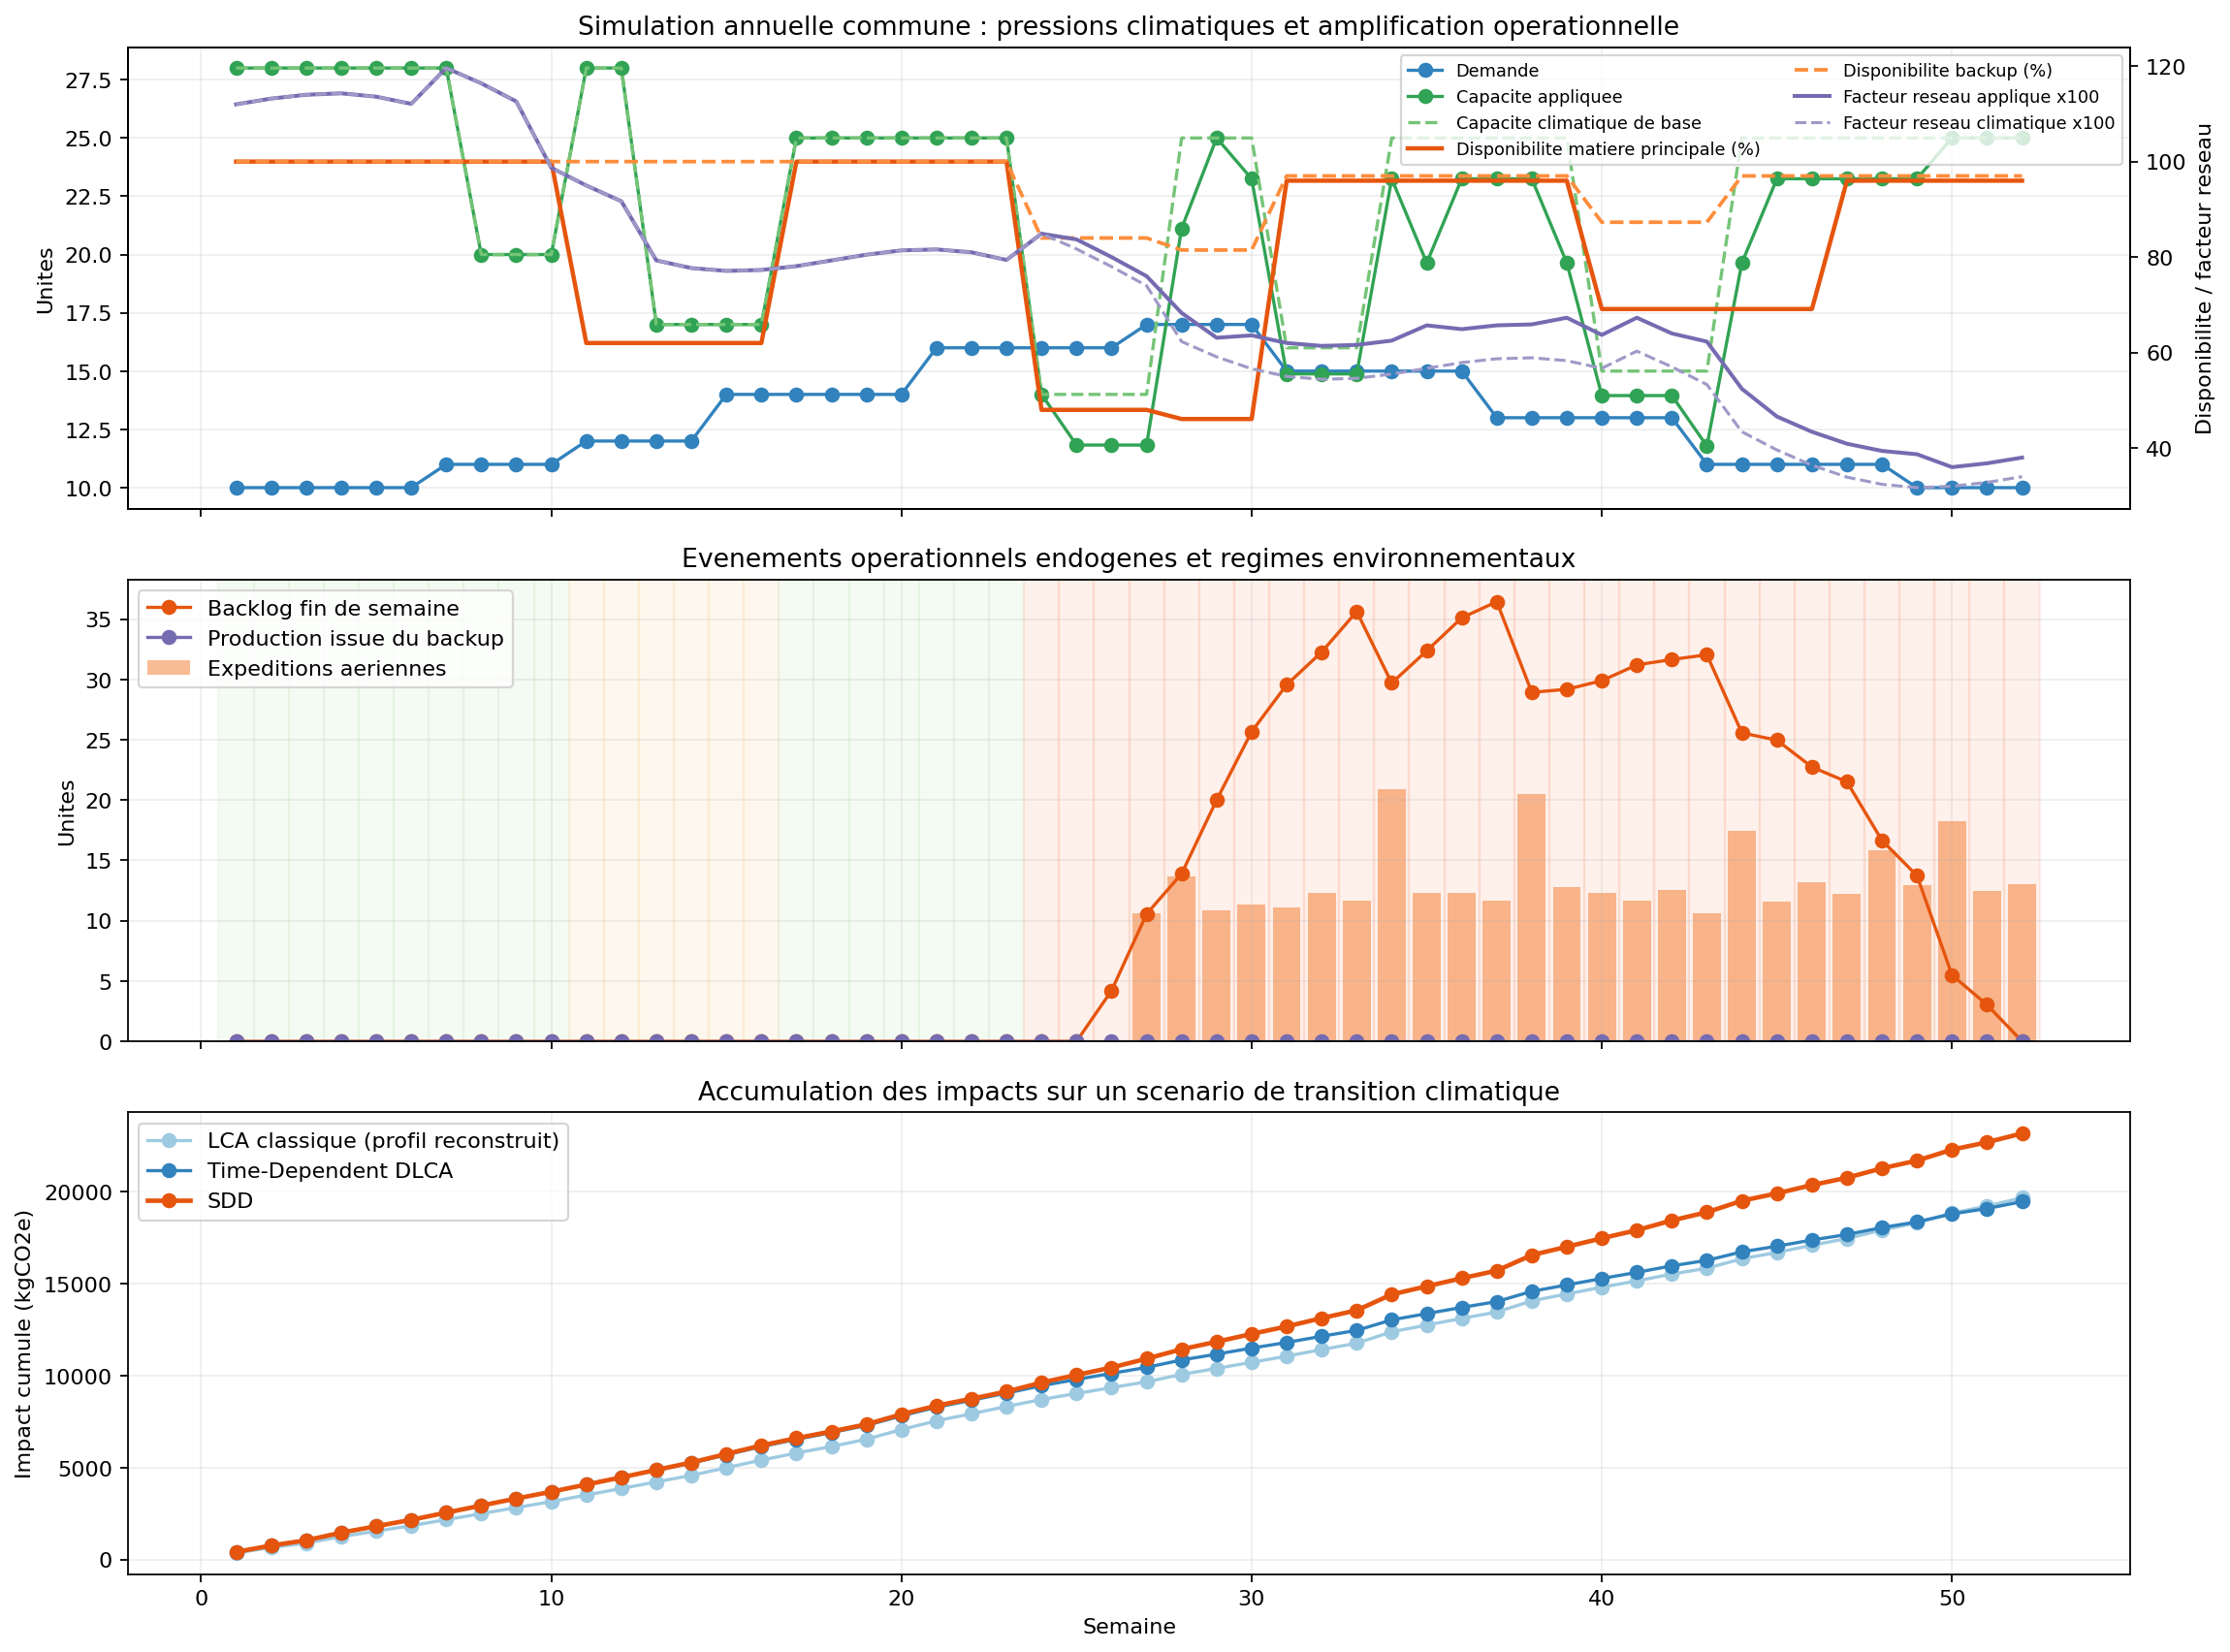

In [15]:
show_image('poc_climate_transition_showcase.png', width=1200)

### Lecture attendue

- Dans ce scénario, la `Time-Dependent DLCA` reste supérieure à la `LCA classique`, mais l'écart reste modéré tant que l'on ne regarde que la chronologie exogène des flux et du facteur réseau.
- Le saut principal vient du `SDD`, qui internalise les tensions matières, le recours au `backup`, les régimes de backlog et les expéditions d'urgence.
- La lecture en **régimes environnementaux** devient ici particulièrement utile : on ne suit plus seulement des semaines "plus ou moins carbonées", mais des modes de fonctionnement distincts du système.
- Cette annexe renforce donc l'idée que l'impact environnemental d'une supply chain en transition climatique est une propriété émergente de ses **transitions de régime**, pas seulement de la trajectoire de décarbonation du réseau.


In [16]:
pd.read_csv(CSV_DIR / 'poc_climate_policy_summary.csv')

,policy_name,policy_label,same_week_service_pct,fill_rate_pct,final_backlog_units,peak_backlog_units,total_cost,classical_total_kgCO2e,time_dependent_dlca_total_kgCO2e,dynamic_total_kgCO2e,sddlca_total_kgCO2e,hidden_carbon_vs_td_dlca,hidden_carbon_vs_dynamic,hidden_carbon_vs_classical
0,baseline,Reference,93.25,100.00,0.00,36.44,57053.41,19673.48,19457.82,19457.82,23169.80,3711.98,3711.98,3496.33
1,backup_early,Backup anticipe,93.25,100.00,0.00,36.44,57053.41,19673.48,19457.82,19457.82,23169.80,3711.98,3711.98,3496.33
2,inventory_buffer,Stock tampon,98.42,100.00,0.00,10.66,43496.93,20118.31,20022.80,20022.80,21968.63,1945.84,1945.84,1850.32
3,low_carbon,Discipline carbone,91.19,98.54,9.83,46.76,61978.37,19324.08,19079.28,19079.28,22802.94,3723.66,3723.66,3478.86
4,service_first,Service prioritaire,97.29,100.00,0.00,16.80,45756.57,20075.52,19944.45,19944.45,22514.27,2569.83,2569.83,2438.75


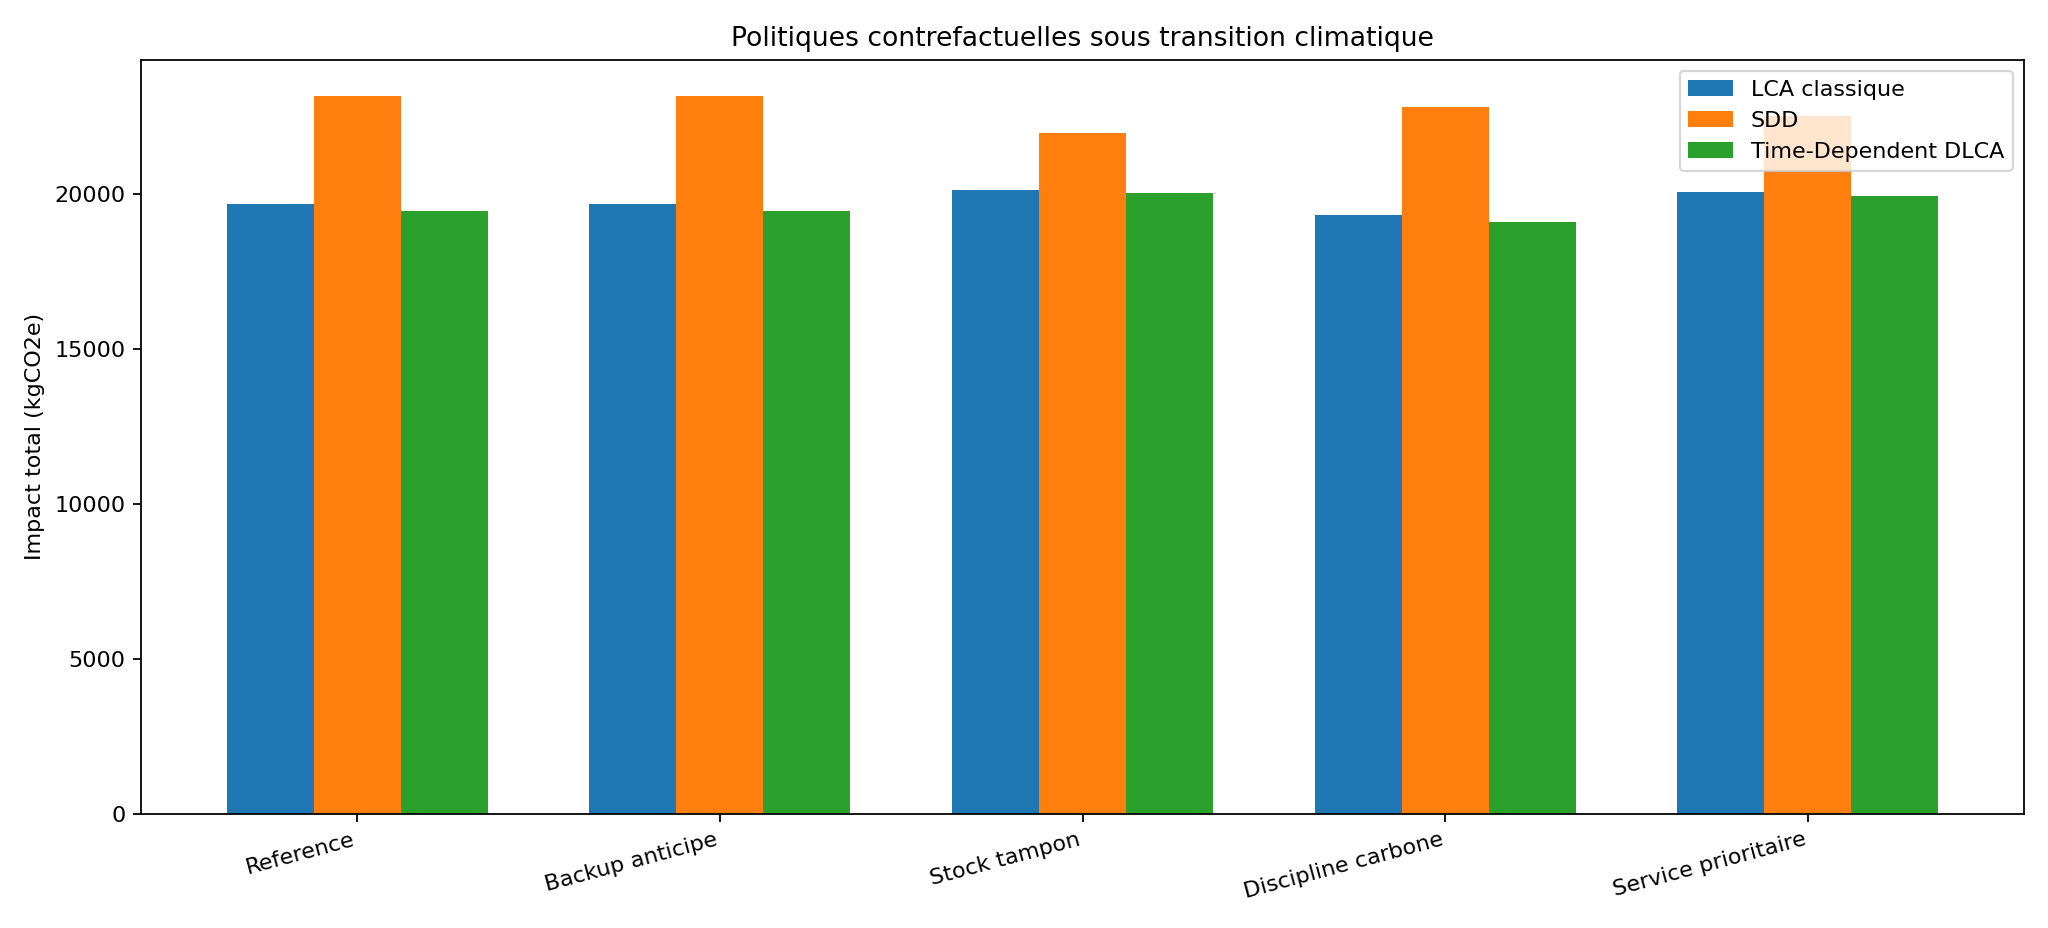

In [17]:
show_image('poc_climate_policy_comparison.png', width=1050)